# **Banking Customer Churn Analysis**

## **STEP 1: BUSINESS PROBLEM DEFINITION**

### **1.1 Business Background**

Banks invest significant resources in acquiring new customers through marketing campaigns, promotions, and relationship-building activities.

However, customer acquisition costs are typically much higher than customer retention costs. When customers leave the bank, it can result in:
*   Loss of revenue
*   Reduced customer lifetime value
*   Increased acquisition costs
*   Lower market competitiveness

Therefore, identifying customers who are likely to churn is critical for improving customer retention and maximizing profitability.

### **1.2 Business Problem Statement**

The bank is experiencing customer attrition, where some customers stop using banking services or close their accounts.

Currently, the bank has no proactive system to identify customers who are at risk of leaving.

The challenge is to analyze customer demographics, account information, transaction behavior, and engagement patterns to identify the factors that contribute to churn and build a predictive model that can detect high-risk customers before they leave.

### **1.3 Business Objective**

The primary objective of this project is to:

* Analyze customer behavior and churn patterns.
* Identify key factors influencing customer churn.
* Segment customers based on churn risk.
* Develop machine learning models to predict customer churn.
* Provide actionable recommendations to improve customer retention.

### **1.4 Analytical Objectives**

This project aims to answer the following business questions:

**Customer Profile Analysis**
* Which age groups have the highest churn rates?
* Does gender influence churn behavior?
* Which occupations experience higher churn?

**Financial Analysis**
* Do customers with low balances churn more frequently?
* Does net worth influence churn?
* How does account activity affect churn?

**Behavioral Analysis**
* Do inactive customers churn more often?
* Does transaction frequency impact churn?
* Does customer tenure influence retention?

**Predictive Analysis**
* Can churn be accurately predicted using historical customer data?
* Which variables contribute most to churn prediction?

### **1.5 Business Impact**

A successful churn prediction system can help the bank:

**Reduce Customer Attrition**

Identify at-risk customers before they leave.

**Increase Revenue**

Retaining customers helps maintain recurring revenue streams.

**Improve Customer Satisfaction**

Targeted engagement strategies can improve customer experience.

**Optimize Marketing Costs**

Focus retention campaigns on customers with the highest churn probability.

**Enhance Decision-Making**

Provide data-driven insights for business and relationship managers.

### **1.6 Success Criteria**

The project will be considered successful if:

**Business Success**
* High-risk customers can be identified early.
* Retention campaigns can be targeted effectively.
* Churn-related insights are actionable.

**Analytical Success**

The model achieves strong performance based on:
* Precision
* Recall
* F1 Score
* ROC-AUC Score

Since churn prediction is an imbalanced classification problem, particular emphasis will be placed on Recall and ROC-AUC.

## Project Workflow

This project follows an end-to-end Customer Churn Analytics workflow, beginning with data preparation and exploratory analysis, followed by machine learning model development, predictive analytics, and business recommendations.

Workflow:

Data Collection -> Data Cleaning -> Exploratory Data Analysis (EDA) -> Feature Engineering -> Data Preprocessing -> Machine Learning Model Development -> Model Evaluation & Cross Validation -> Final Model Selection -> Feature Importance Analysis -> Customer Churn Prediction -> Business Insights & Recommendations -> Power BI Dashboard Development

## **STEP 2: DATA UNDERSTANDING**

### **2.1 Objective**
To explore the dataset structure, understand the available customer information, identify data types, and gain an initial understanding of customer demographics, financial attributes, and churn behavior.

In [1]:
! pip install numpy
! pip install pandas
! pip install matplotlib
! pip install seaborn
! pip install scipy
! pip install scikit-learn
! pip install xgboost

### **2.2 Import Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score

sns.set_style("whitegrid")

### **2.3 Load Dataset**

**Read CSV**

In [3]:
df = pd.read_csv(r"D:\DIVYA\Data Analytics\DA Projects\Power BI\Customer Churn Prediction Analysis\data\raw\churn_prediction.csv")

**Preview Data**

In [4]:
df.head(5)

,customer_id,vintage,vintage (in years),vintage_segment,age,Age Group,gender,dependents,occupation,city,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,5.8,Loyal Customer,66,55+,Male,0,self_employed,187,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,21-05-2019
1,2,2348,6.4,Loyal Customer,35,26-35,Male,0,self_employed,0,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,01-11-2019
2,4,2194,6.0,Loyal Customer,31,26-35,Male,0,salaried,146,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,6.4,Loyal Customer,90,55+,Not to disclose,0,self_employed,1020,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,06-08-2019
4,6,1579,4.3,Regular Customer,42,36-45,Male,2,self_employed,1494,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,03-11-2019


**Check Shape**

In [5]:
df.shape

(28382, 25)

### Business Interpretation

The dataset was successfully loaded into the Python environment and contains customer demographic, financial, and banking relationship information that will be used to analyze customer churn patterns.

### **2.4 Dataset Overview**

**Column Analysis**

In [6]:
df.columns

Index(['customer_id', 'vintage', 'vintage (in years)', 'vintage_segment',
       'age', 'Age Group', 'gender', 'dependents', 'occupation', 'city',
       'customer_nw_category', 'branch_code', 'current_balance',
       'balance_segment', 'previous_month_end_balance',
       'average_monthly_balance_prevQ', 'average_monthly_balance_prevQ2',
       'current_month_credit', 'previous_month_credit', 'current_month_debit',
       'previous_month_debit', 'current_month_balance',
       'previous_month_balance', 'churn', 'last_transaction'],
      dtype='object')

**Data Types**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   vintage (in years)              28382 non-null  float64
 3   vintage_segment                 28382 non-null  object 
 4   age                             28382 non-null  int64  
 5   Age Group                       28382 non-null  object 
 6   gender                          28382 non-null  object 
 7   dependents                      28382 non-null  int64  
 8   occupation                      28382 non-null  object 
 9   city                            28382 non-null  int64  
 10  customer_nw_category            28382 non-null  int64  
 11  branch_code                     28382 non-null  int64  
 12  current_balance                 

### **2.5 Summary Statistics**

In [8]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
customer_id,28382.0,15143.51,8746.45,1.00,7557.25,15150.50,22706.75,30301.00
vintage,28382.0,2091.14,272.68,73.00,1958.00,2154.00,2292.00,2476.00
vintage (in years),28382.0,5.73,0.75,0.20,5.40,5.90,6.30,6.80
age,28382.0,48.21,17.81,1.00,36.00,46.00,60.00,90.00
dependents,28382.0,0.32,0.96,0.00,0.00,0.00,0.00,52.00
city,28382.0,773.59,446.66,0.00,409.00,834.00,1096.00,1649.00
customer_nw_category,28382.0,2.23,0.66,1.00,2.00,2.00,3.00,3.00
branch_code,28382.0,925.98,937.80,1.00,176.00,572.00,1440.00,4782.00
current_balance,28382.0,7380.55,42598.71,-5503.96,1784.47,3281.26,6635.82,5905904.03
previous_month_end_balance,28382.0,7495.77,42529.35,-3149.57,1906.00,3379.92,6656.54,5740438.63


### **2.6 Target Variable Review**

In [9]:
# How many Churned

df['churn'].value_counts()

churn
0    23122
1     5260
Name: count, dtype: int64

In [10]:
# Churn Rate

df['churn'].mean()*100

np.float64(18.532872947642872)

### Business Interpretation

The initial exploration provides an overview of the dataset structure, feature types, and statistical characteristics. Understanding the dataset before analysis helps identify appropriate preprocessing techniques and potential data quality issues.

## **STEP 3: DATA QUALITY ASSESSMENT**

### **3.1 Objective**
To evaluate the quality of the dataset by identifying missing values, duplicate records, inconsistent data types, and other data issues that may affect analysis and model performance.

### **3.2 Missing Value Analysis**

**Count Missing Values**

In [11]:
missing = df.isnull().sum()

missing = pd.DataFrame({
    'Column': missing.index,
    'Missing Values': missing.values
})

missing

,Column,Missing Values
0,customer_id,0
1,vintage,0
2,vintage (in years),0
3,vintage_segment,0
4,age,0
5,Age Group,0
6,gender,0
7,dependents,0
8,occupation,0
9,city,0


### **3.3 Duplicate Analysis**

**Duplicate Records**

In [12]:
df.duplicated().sum()

np.int64(0)

### Business Interpretation

The data quality assessment confirms whether the dataset is complete and reliable for analysis. Addressing missing values and duplicate records improves model accuracy and ensures trustworthy business insights.

## **STEP 4: FEATURE ENGINEERING**

### **4.1 Objective**
To create meaningful features from existing variables that better represent customer behavior, financial activity, and engagement patterns, thereby improving analytical insights and predictive model performance.

### **4.2 Date Feature Processing**

In [13]:
# Convert String to Date type

df['last_transaction'] = pd.to_datetime(
    df['last_transaction'],
    errors='coerce'
)

C:\Users\acer\AppData\Local\Temp\ipykernel_18588\3210507568.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['last_transaction'] = pd.to_datetime(


In [14]:
print(df['last_transaction'].dtype)

datetime64[ns]


### **4.3 Transaction Recency**

**days_since_last_transaction**

In [15]:
latest_date = df['last_transaction'].max()

df['days_since_last_transaction'] = (
    latest_date - df['last_transaction']
).dt.days

print(df[['last_transaction', 'days_since_last_transaction']].head())

  last_transaction  days_since_last_transaction
0       2019-05-21                        224.0
1       2019-11-01                         60.0
2              NaT                          NaN
3       2019-08-06                        147.0
4       2019-11-03                         58.0


### **4.4 Activity Change Features**

**Balance Change %**

In [16]:
df['balance_change_pct'] = (
    (df['current_month_balance']
     - df['previous_month_balance'])
    /
    (df['previous_month_balance'] + 1)
)

print(df[['balance_change_pct']].head())

   balance_change_pct
0            0.000000
1           -0.260659
2           -0.012593
3            0.372351
4           -0.309869


**Credit Activity Change**

In [17]:
df['credit_change'] = (
    df['current_month_credit']
    -
    df['previous_month_credit']
)

print(df[['credit_change']].head())

   credit_change
0           0.00
1           0.00
2           0.00
3           0.00
4        -714.28


**Debit Activity Change**

In [18]:
df['debit_change'] = (
    df['current_month_debit']
    -
    df['previous_month_debit']
)

print(df[['debit_change']].head())

   debit_change
0          0.00
1       5385.71
2       5787.50
3      -2142.86
4       -949.44


## **STEP 5: TARGET VARIABLE ANALYSIS**

### **5.1 Churn Distribution**

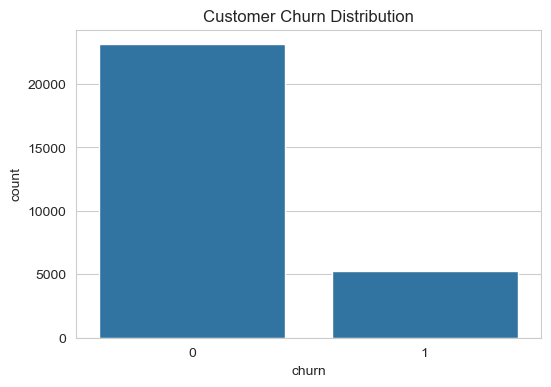

In [19]:
# How many customers churned?

plt.figure(figsize=(6,4))

sns.countplot(
    x='churn',
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

## **STEP 6: EXPLORATORY DATA ANALYSIS**

### **6.1 Numerical Analysis**



In [20]:
numerical_cols = [
    'age',
    'dependents',
    'vintage',
    'current_balance',
    'previous_month_end_balance',
    'average_monthly_balance_prevQ',
    'average_monthly_balance_prevQ2',
    'current_month_credit',
    'previous_month_credit',
    'current_month_debit',
    'previous_month_debit',
    'current_month_balance',
    'previous_month_balance',
    'days_since_last_transaction',
    'balance_change_pct',
    'credit_change',
    'debit_change'
]

**6.1.1 Summary Statistics**

In [21]:
df[numerical_cols].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,28382.0,48.21,17.81,1.00,36.00,46.00,60.00,90.00
dependents,28382.0,0.32,0.96,0.00,0.00,0.00,0.00,52.00
vintage,28382.0,2091.14,272.68,73.00,1958.00,2154.00,2292.00,2476.00
current_balance,28382.0,7380.55,42598.71,-5503.96,1784.47,3281.26,6635.82,5905904.03
previous_month_end_balance,28382.0,7495.77,42529.35,-3149.57,1906.00,3379.92,6656.54,5740438.63
average_monthly_balance_prevQ,28382.0,7496.78,41726.22,1428.69,2180.95,3542.86,6666.89,5700289.57
average_monthly_balance_prevQ2,28382.0,7124.21,44575.81,-16506.10,1832.51,3359.60,6517.96,5010170.10
current_month_credit,28382.0,3433.25,77071.45,0.01,0.31,0.61,707.27,12269845.39
previous_month_credit,28382.0,3261.69,29688.89,0.01,0.33,0.63,749.24,2361808.29
current_month_debit,28382.0,3658.74,51985.42,0.01,0.41,91.93,1360.44,7637857.36


**6.1.2 Skewness Analysis**

In [22]:
skewness = pd.DataFrame({
    'Feature': numerical_cols,
    'Skewness': df[numerical_cols].skew().values
})

skewness.sort_values(
    by='Skewness',
    ascending=False
)

,Feature,Skewness
7,current_month_credit,143.315551
15,credit_change,138.316723
9,current_month_debit,115.620280
16,debit_change,106.793955
3,current_balance,99.030683
11,current_month_balance,97.313457
5,average_monthly_balance_prevQ,96.648620
12,previous_month_balance,93.398645
4,previous_month_end_balance,92.948220
6,average_monthly_balance_prevQ2,88.893453


**6.1.3 Distribution Analysis**

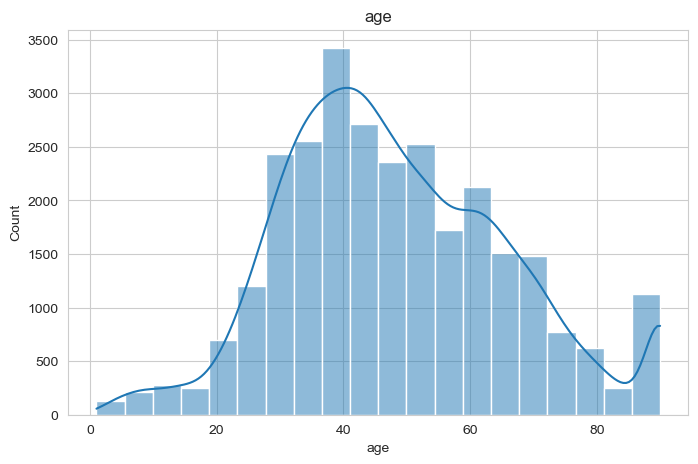

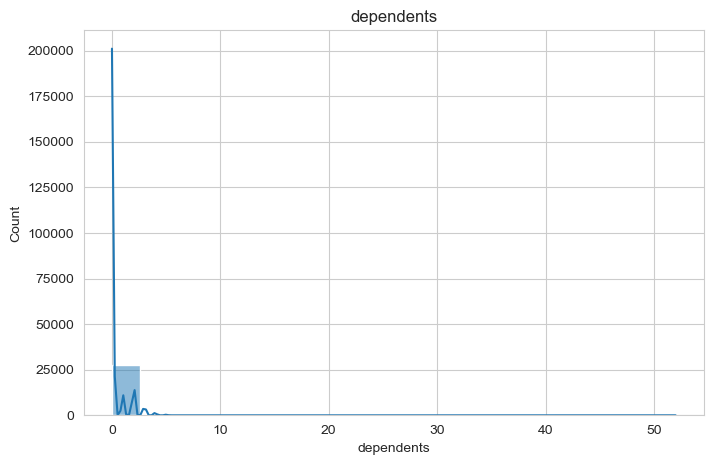

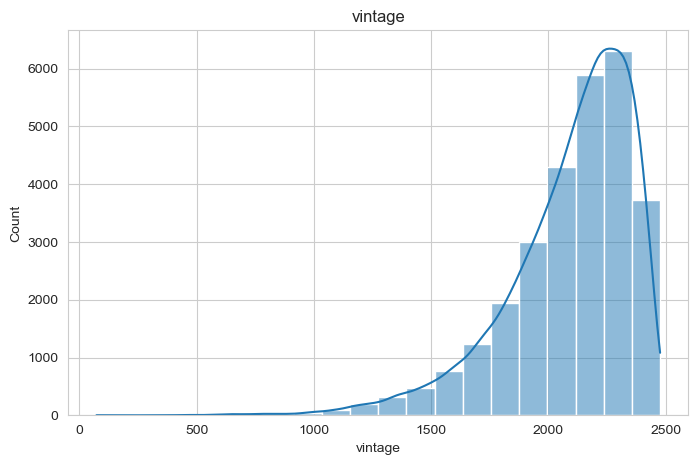

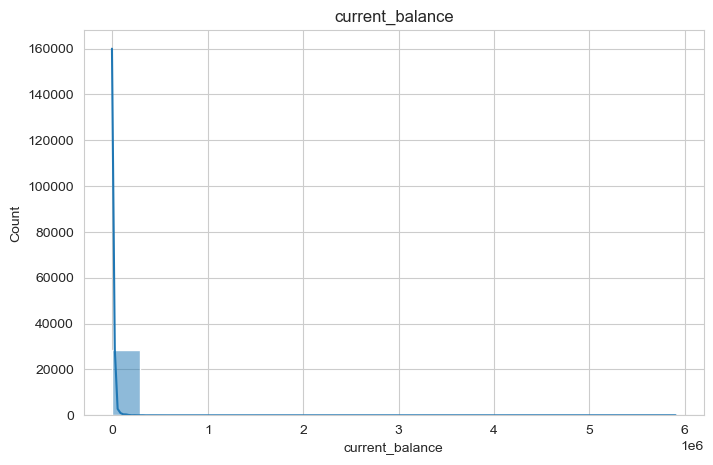

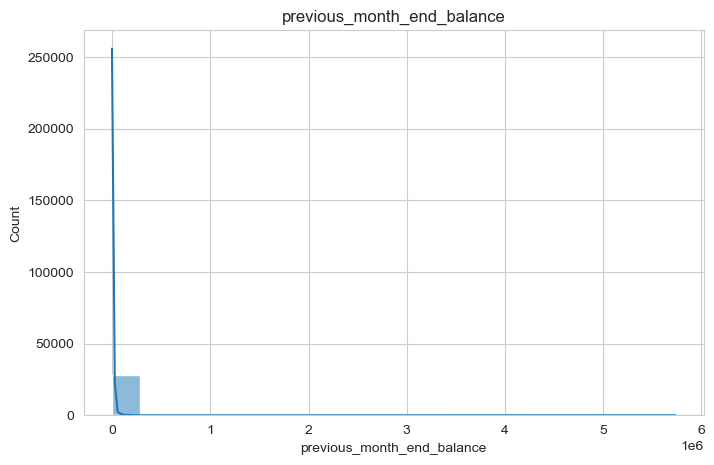

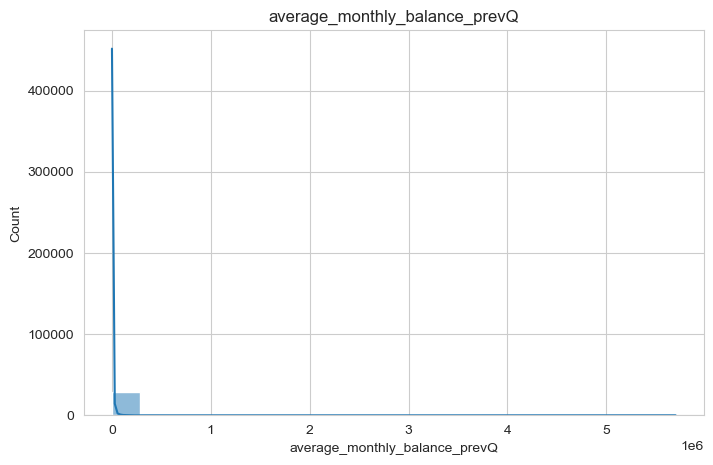

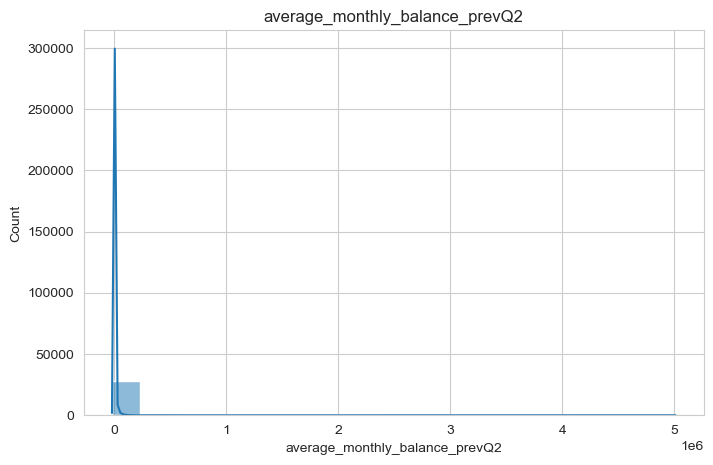

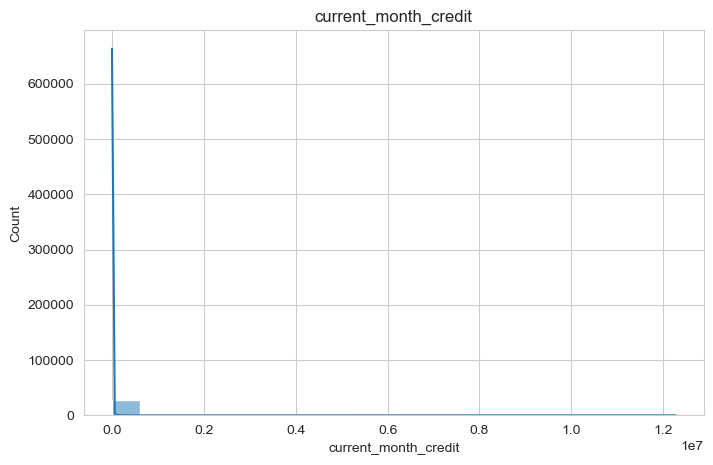

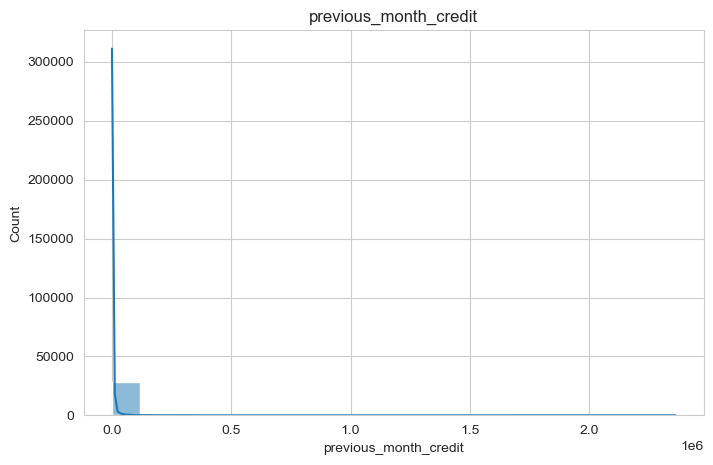

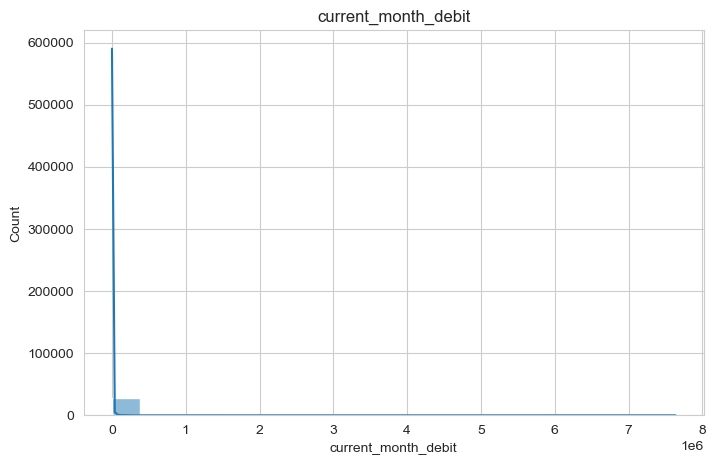

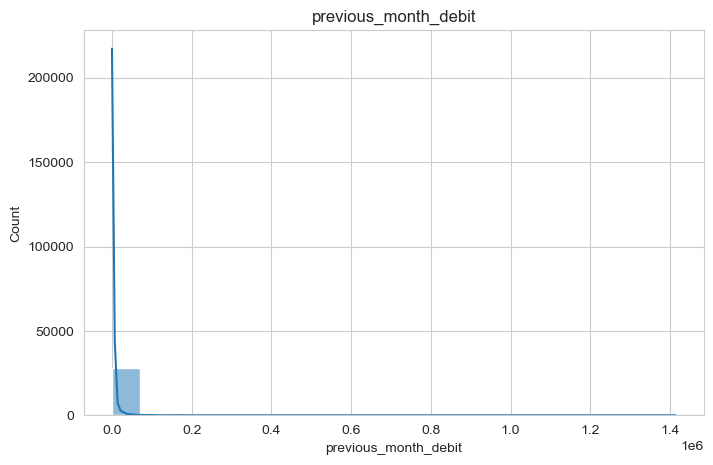

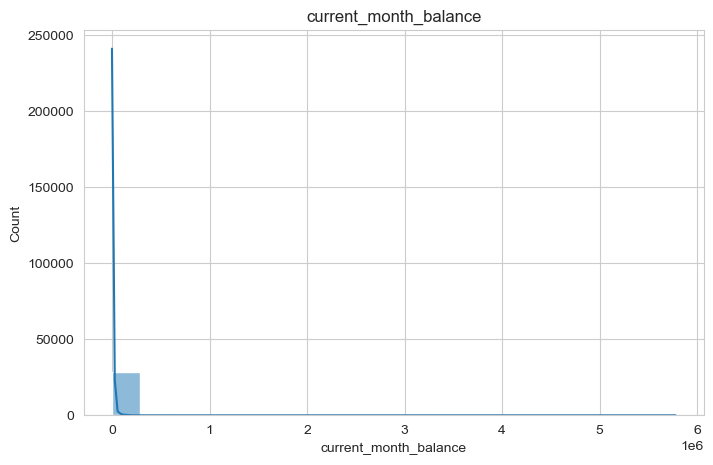

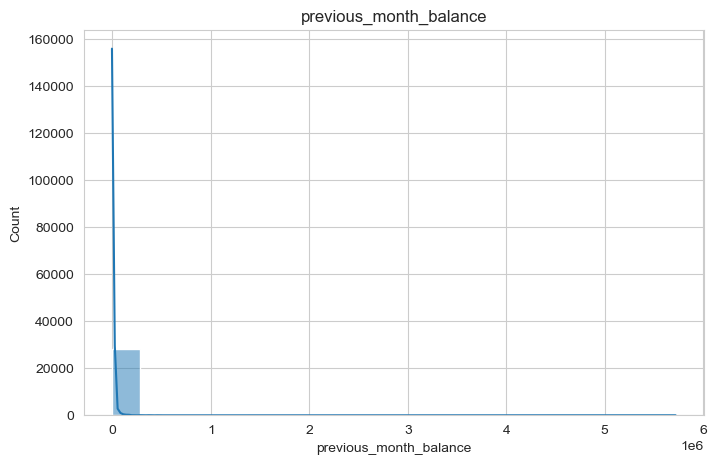

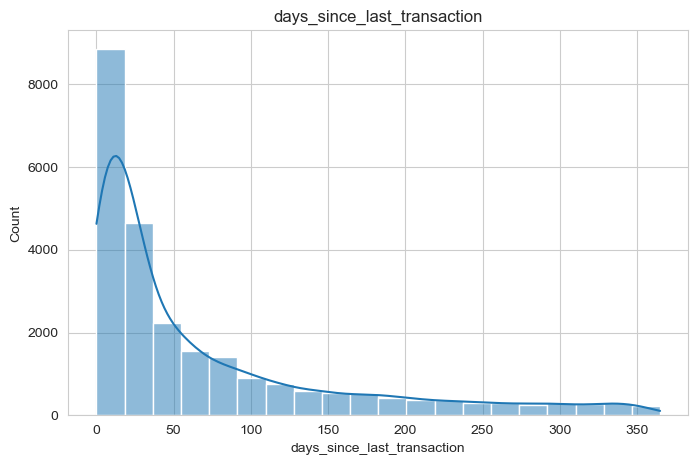

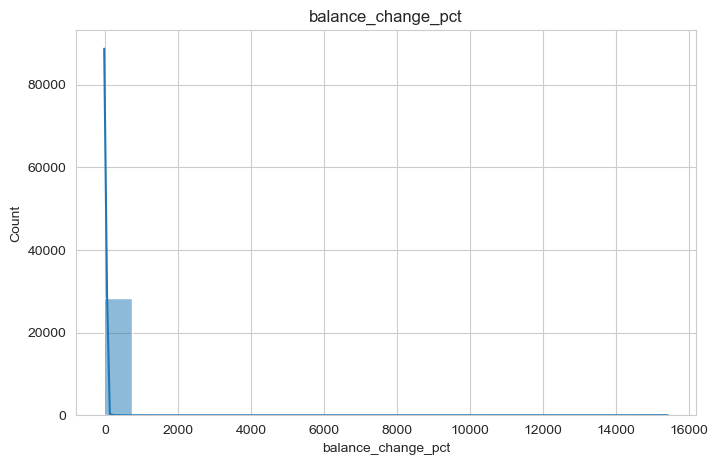

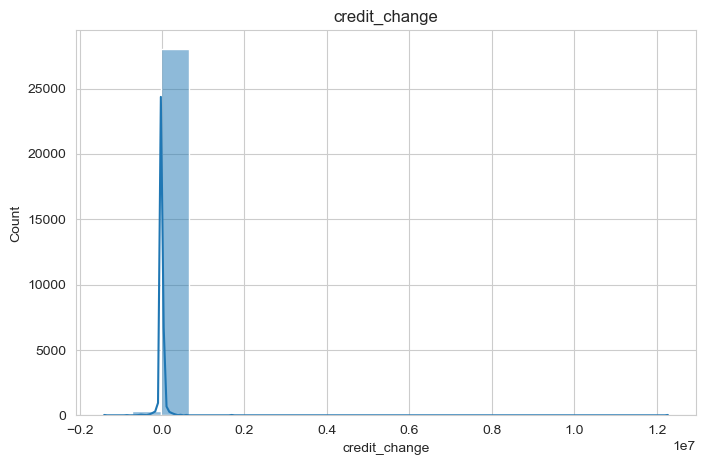

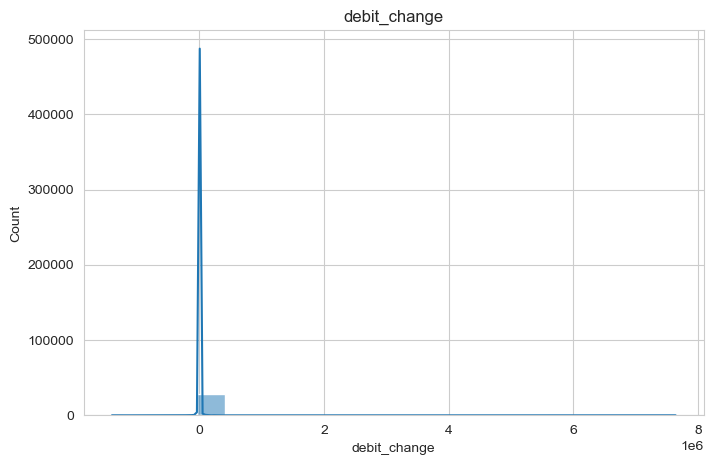

In [23]:
# Histogram

for col in numerical_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(col)
    plt.show()

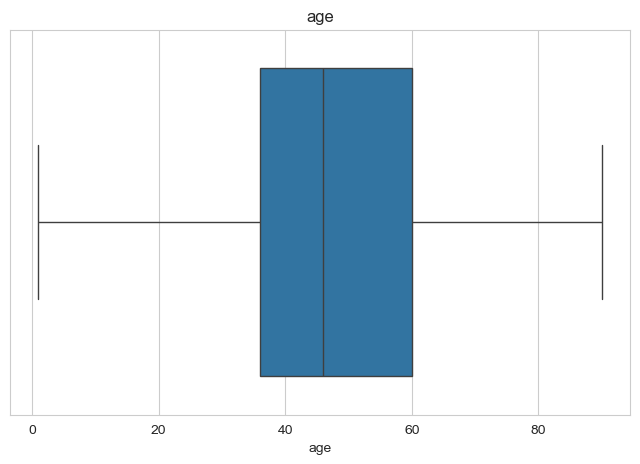

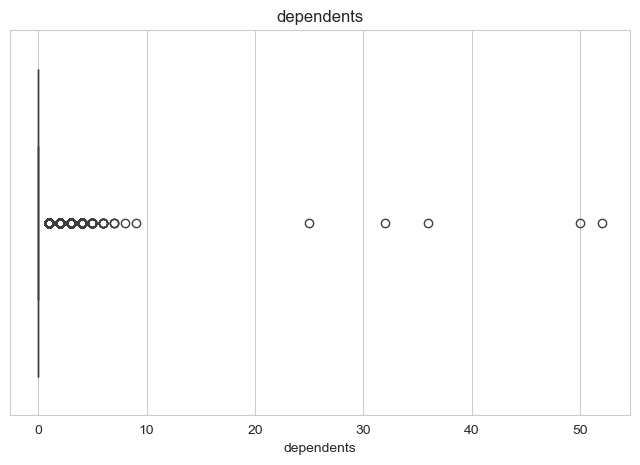

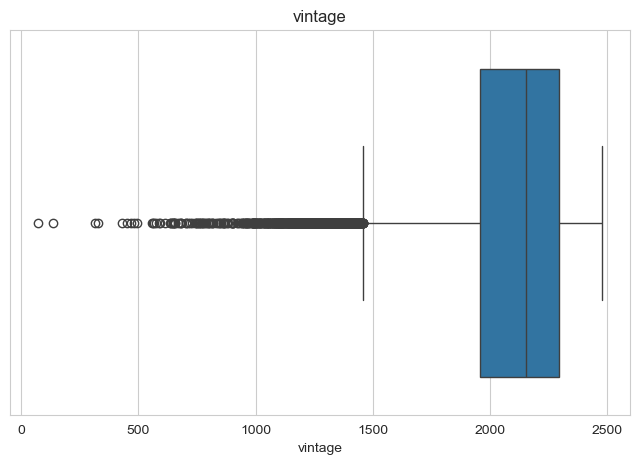

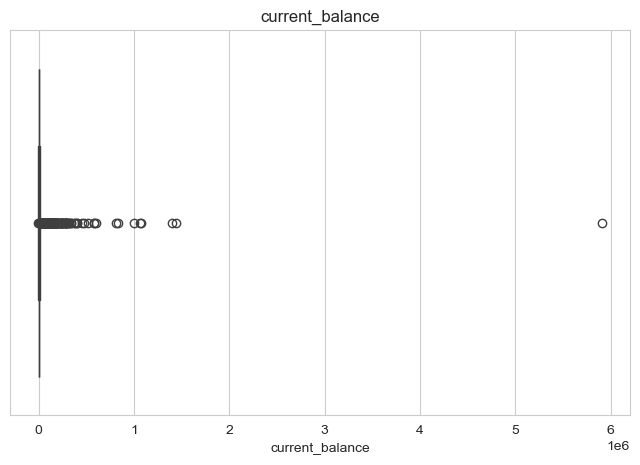

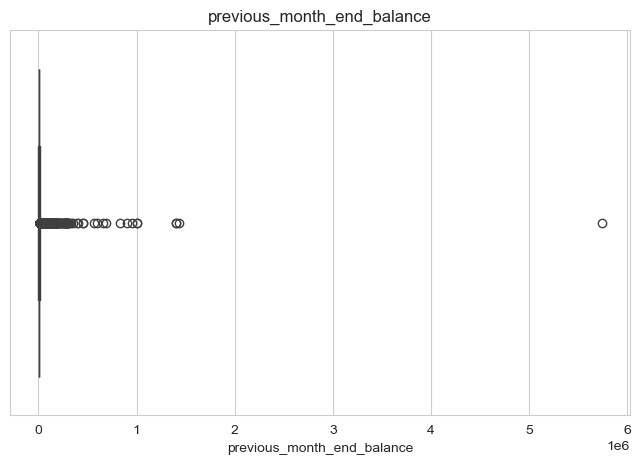

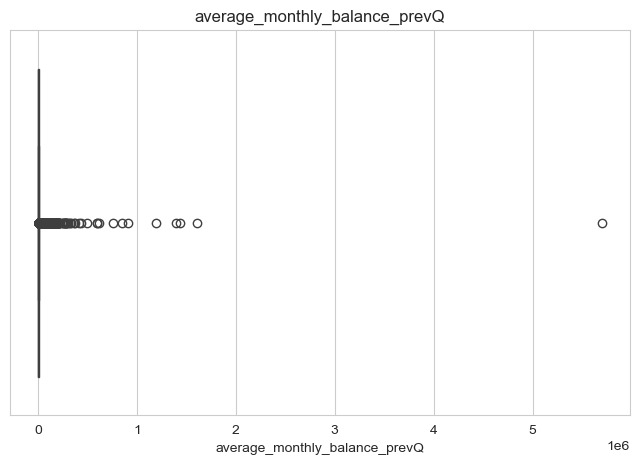

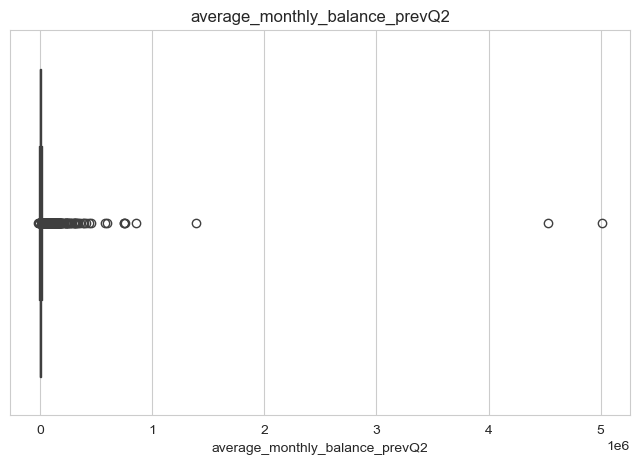

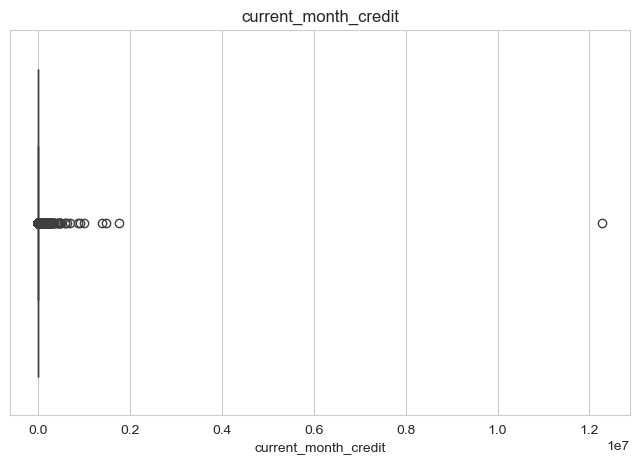

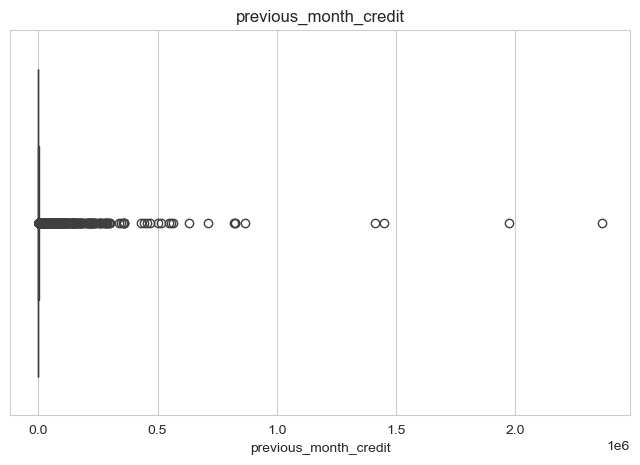

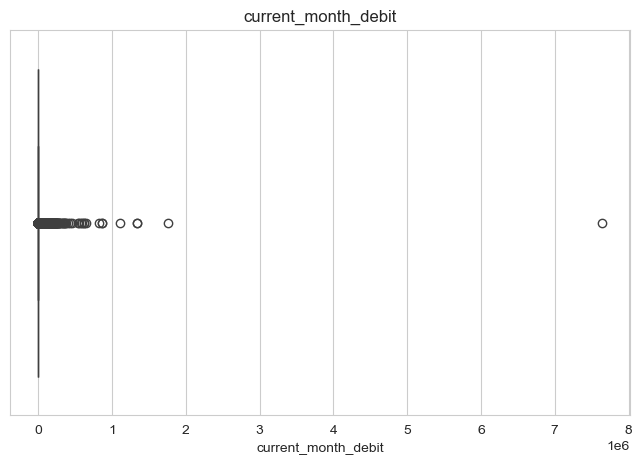

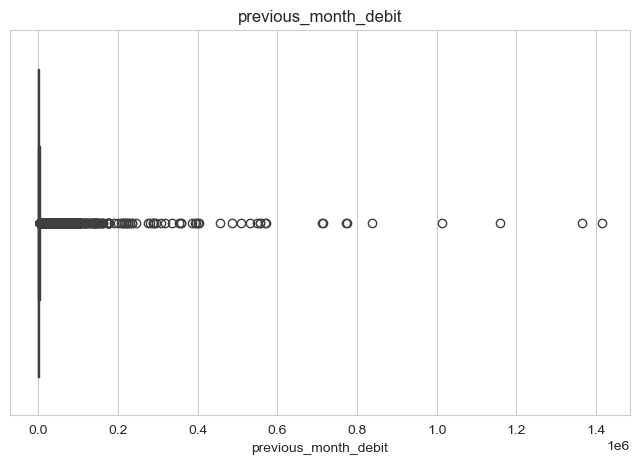

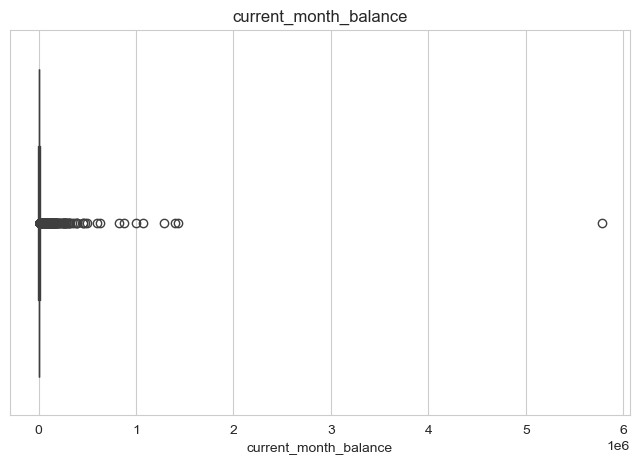

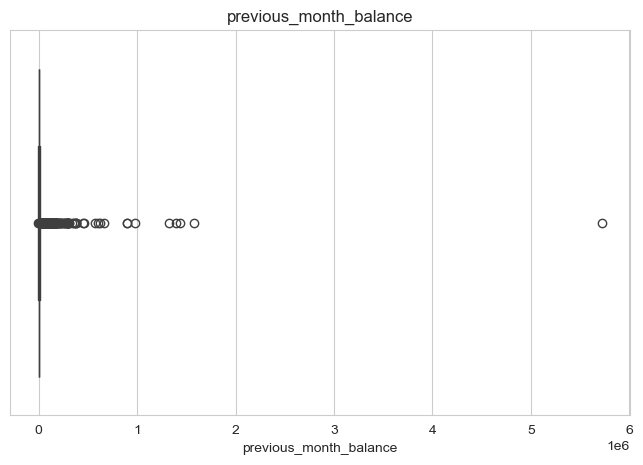

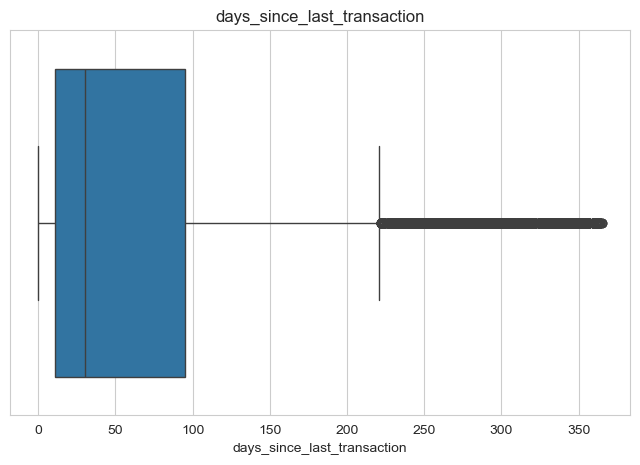

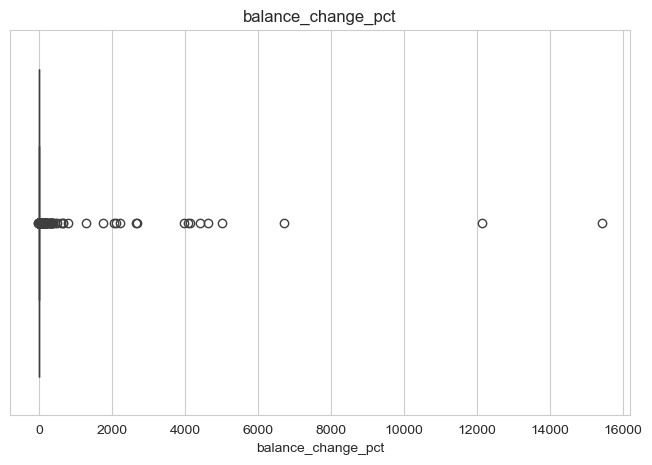

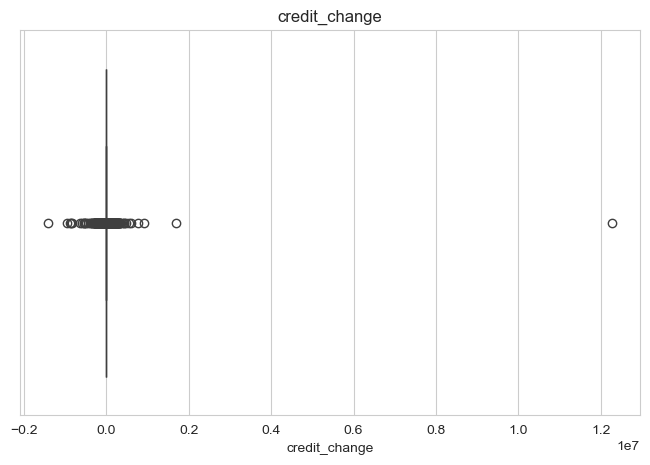

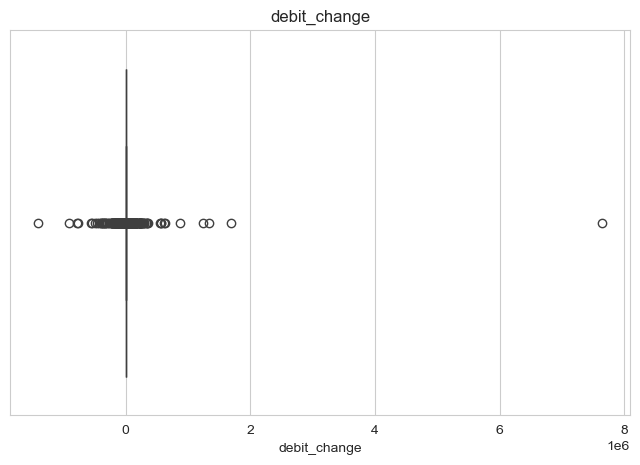

In [24]:
# Box Plot

for col in numerical_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### **6.2 Categorical Analysis**

In [25]:
categorical_cols = [
    'gender',
    'occupation',
    'city',
    'customer_nw_category',
    'balance_segment',
    'Age Group',
    'vintage_segment'
]

**6.2.1 Frequency Distribution Analysis**

In [26]:
for col in categorical_cols:
    display(
        pd.DataFrame({
            'Count': df[col].value_counts(),
            'Percentage': round(
                df[col].value_counts(normalize=True)*100,
                2
            )
        })
    )

,Count,Percentage
gender,,
Male,16548,58.30
Female,11309,39.85
Not to disclose,525,1.85


,Count,Percentage
occupation,,
self_employed,17476,61.57
salaried,6704,23.62
student,2058,7.25
retired,2024,7.13
Others,80,0.28
company,40,0.14


,Count,Percentage
city,,
1020,3479,12.26
1096,2016,7.10
409,1334,4.70
146,1291,4.55
834,1138,4.01
...,...,...
748,1,0.00
1099,1,0.00
108,1,0.00


,Count,Percentage
customer_nw_category,,
2,14559,51.30
3,10112,35.63
1,3711,13.08


,Count,Percentage
balance_segment,,
Low,24111,84.95
Medium,3867,13.62
High,404,1.42


,Count,Percentage
Age Group,,
55+,9157,32.26
36-45,6805,23.98
46-55,5325,18.76
26-35,5010,17.65
18-25,2085,7.35


,Count,Percentage
vintage_segment,,
Loyal Customer,23838,83.99
Regular Customer,4507,15.88
New Customer,37,0.13


**6.2.2 Gender Distribution**

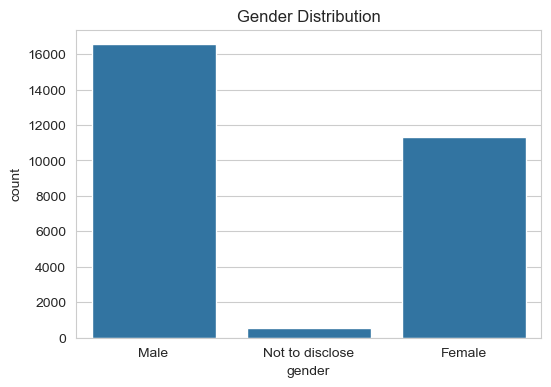

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='gender',
    data=df
)

plt.title("Gender Distribution")
plt.show()

**6.2.3 Occupation Distribution**

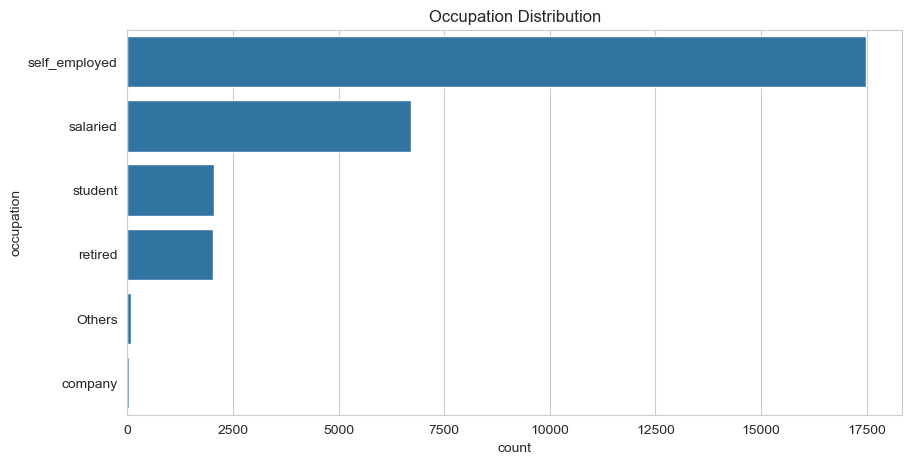

In [28]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='occupation',
    data=df,
    order=df['occupation'].value_counts().index
)

plt.title("Occupation Distribution")
plt.show()

## **STEP 7: CHURN ANALYSIS**

### **7.1 Numerical Features vs Churn**

**7.1.1 Age vs Churn**

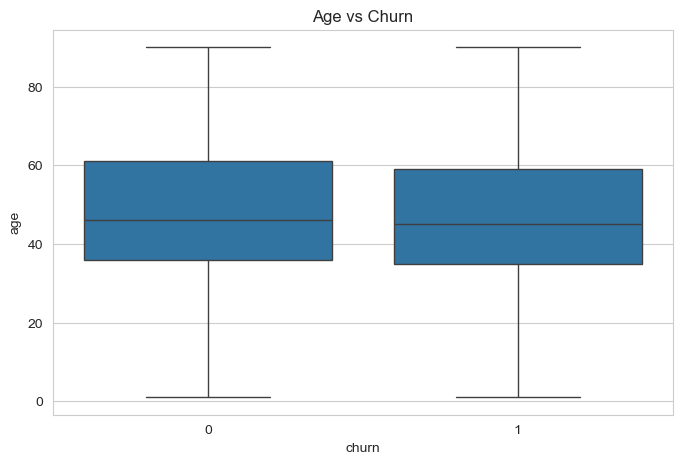

In [29]:
# Are older customers leaving more?

plt.figure(figsize=(8,5))

sns.boxplot(
    y='age',
    x='churn',
    data=df
)

plt.title("Age vs Churn")
plt.show()

**7.1.2 Balance vs Churn**

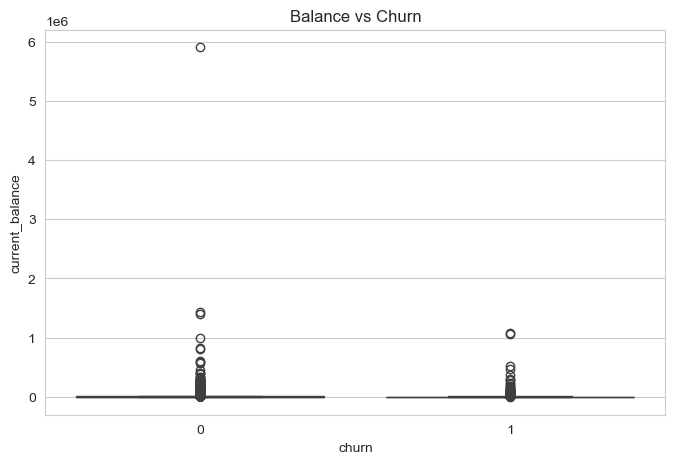

In [30]:
# Does low balance increase churn?

plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn',
    y='current_balance',
    data=df
)

plt.title("Balance vs Churn")
plt.show()

**7.1.3 Credit Activity vs Churn**

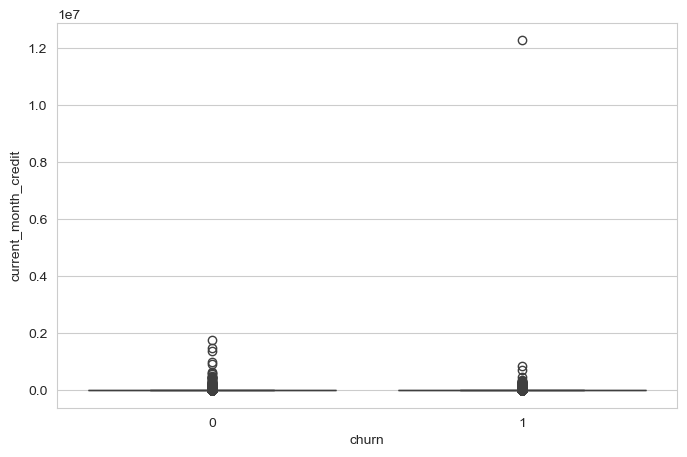

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn',
    y='current_month_credit',
    data=df
)
plt.show()

**7.1.4 Debit Activity vs Churn**

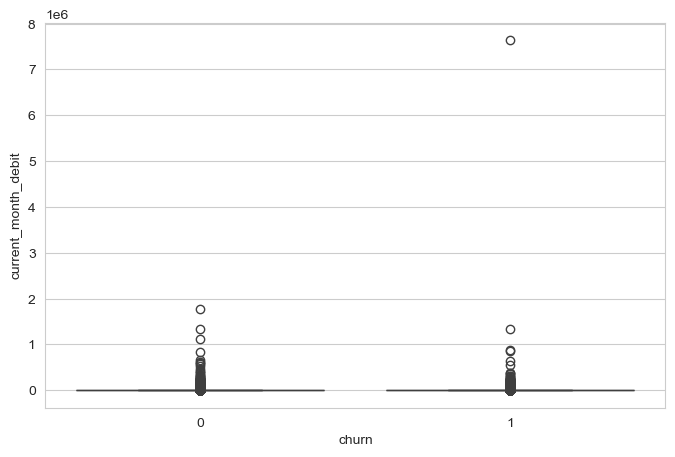

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn',
    y='current_month_debit',
    data=df
)
plt.show()

**7.1.5 Vintage vs Churn**

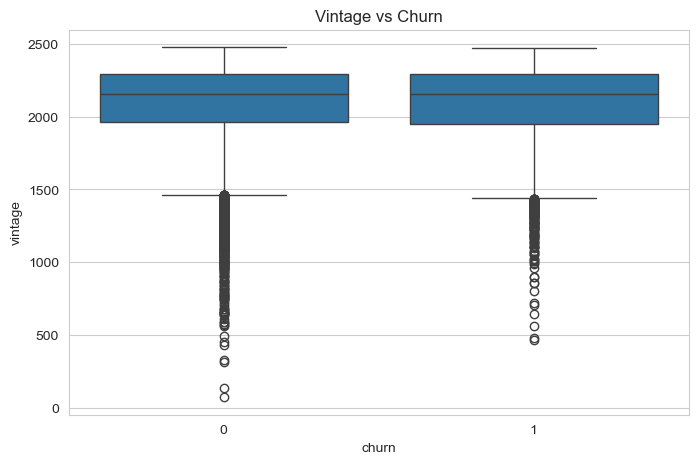

In [33]:
# Are newer customers leaving?

plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn',
    y='vintage',
    data=df
)

plt.title("Vintage vs Churn")
plt.show()

**7.1.6 Transaction Recency vs Churn**

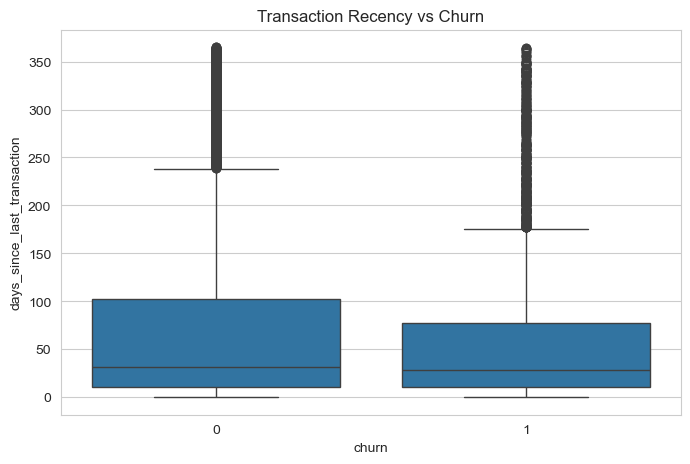

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn',
    y='days_since_last_transaction',
    data=df
)

plt.title("Transaction Recency vs Churn")
plt.show()

### **7.2 Categorical Features vs Churn**

**7.2.1 Gender vs Churn**

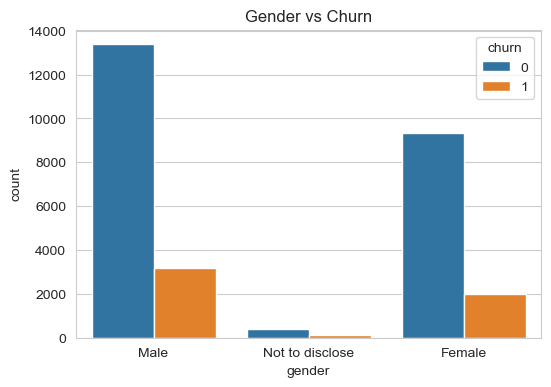

In [35]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='gender',
    hue='churn',
    data=df
)

plt.title("Gender vs Churn")
plt.show()

**7.2.2 Occupation vs Churn**

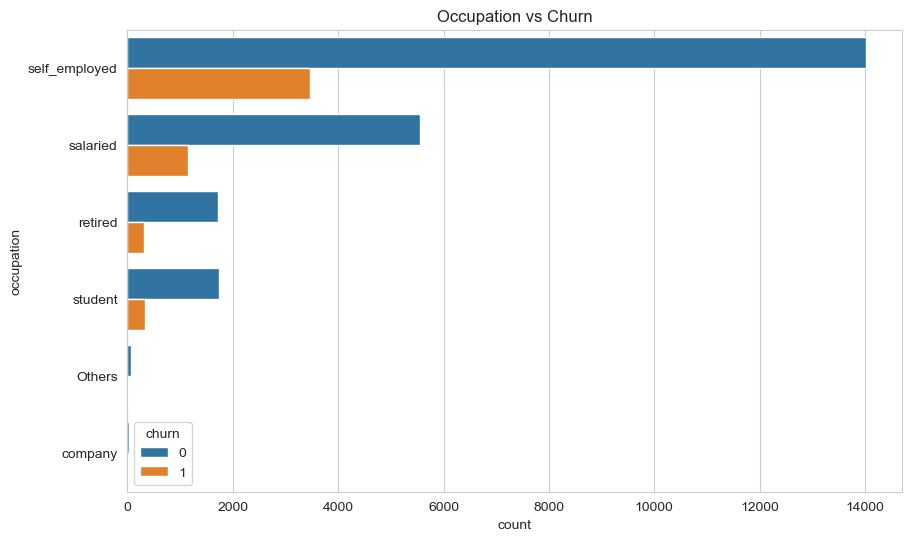

In [36]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='occupation',
    hue='churn',
    data=df
)

plt.title("Occupation vs Churn")
plt.show()

### **7.2.3 Net Worth Category vs Churn**

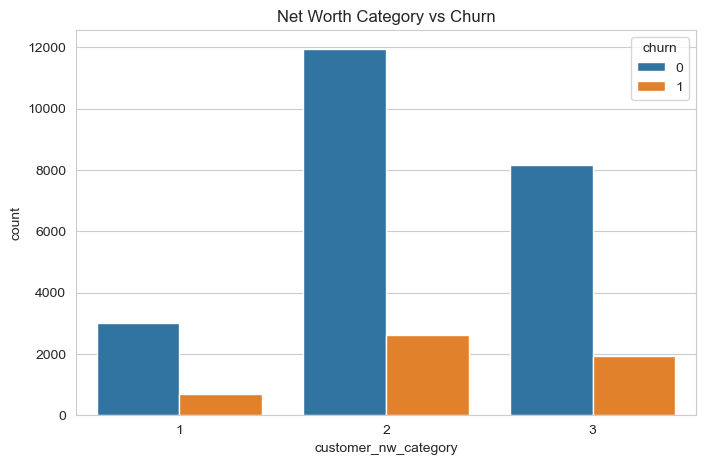

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='customer_nw_category',
    hue='churn',
    data=df
)

plt.title("Net Worth Category vs Churn")
plt.show()

## **STEP 8: CHURN RATE ANALYSIS**

### **8.1 Age Group Churn Rate**

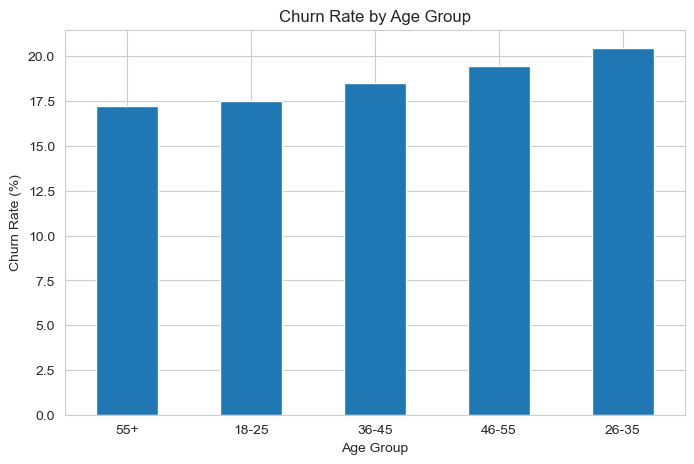

In [38]:
age_churn = (
    df.groupby('Age Group')['churn']
      .mean()
      .mul(100)
      .round(2)
      .sort_values()
)

plt.figure(figsize=(8,5))

age_churn.plot(
    kind='bar'
)

plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.show()

### **8.2 Gender Churn Rate**

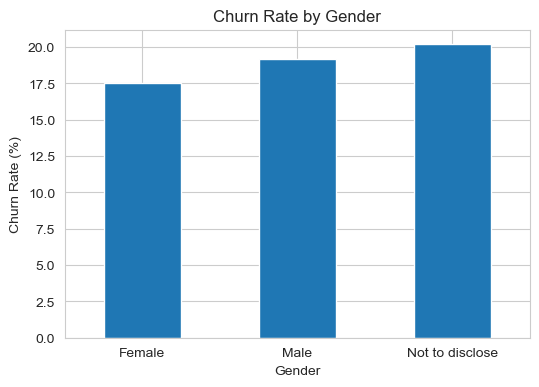

In [39]:
gender_churn = (
    df.groupby('gender')['churn']
      .mean()*100
).round(2)

plt.figure(figsize=(6,4))

gender_churn.plot(
    kind='bar'
)

plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.show()

### **8.3 Occupation Churn Rate**

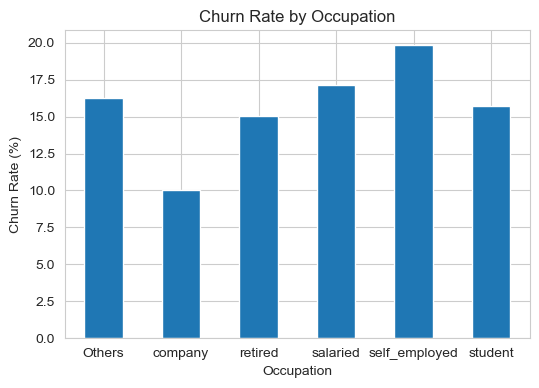

In [40]:
occupation_churn = (
    df.groupby('occupation')['churn']
      .mean()*100
).round(2)

occupation_churn.sort_values(ascending=False)

plt.figure(figsize=(6,4))

occupation_churn.plot(
    kind='bar'
)

plt.title('Churn Rate by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.show()

### **8.4 Net Worth Churn Rate**

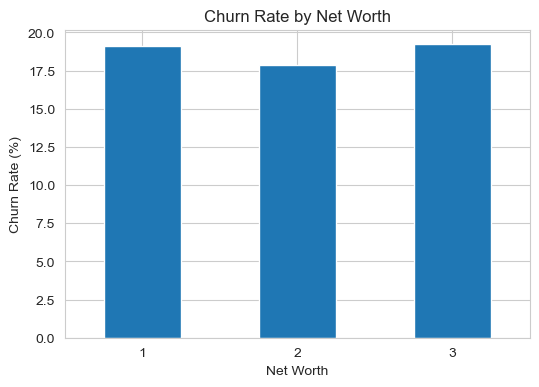

In [41]:
nw_churn = (
    df.groupby('customer_nw_category')['churn']
      .mean()*100
).round(2)

plt.figure(figsize=(6,4))

nw_churn.plot(
    kind='bar'
)

plt.title('Churn Rate by Net Worth')
plt.xlabel('Net Worth')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.show()

### **8.5 Balance Segment Churn Rate**

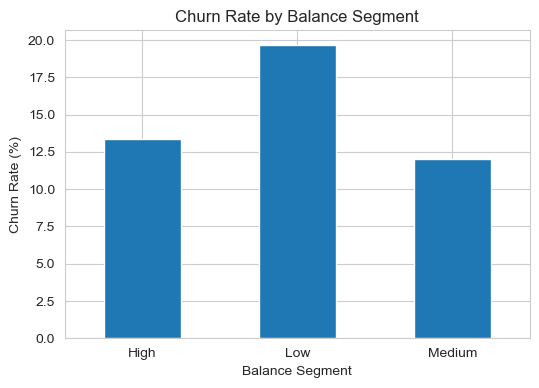

In [42]:
balance_churn = (
    df.groupby('balance_segment')['churn']
      .mean()*100
).round(2)

plt.figure(figsize=(6,4))

balance_churn.plot(
    kind='bar'
)

plt.title('Churn Rate by Balance Segment')
plt.xlabel('Balance Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.show()

### **8.6 Vintage Segment Churn Rate**

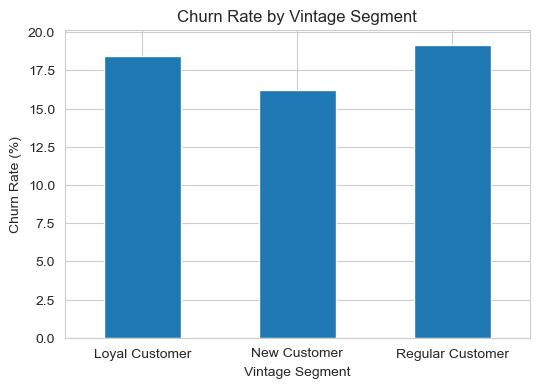

In [43]:
vintage_churn = (
    df.groupby('vintage_segment')['churn']
      .mean()*100
).round(2)

plt.figure(figsize=(6,4))

vintage_churn.plot(
    kind='bar'
)

plt.title('Churn Rate by Vintage Segment')
plt.xlabel('Vintage Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.show()

### **8.7 Dependents Churn Rate**

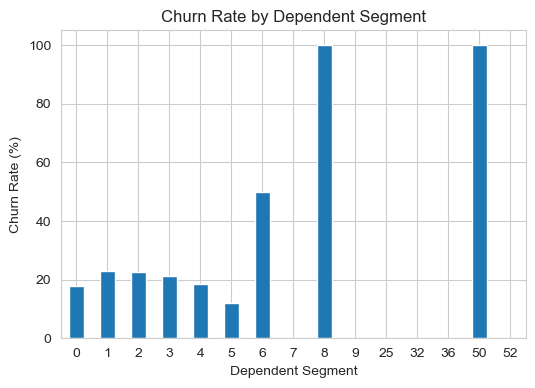

In [44]:
dependent_churn = (
    df.groupby('dependents')['churn']
      .mean()*100
).round(2)

plt.figure(figsize=(6,4))

dependent_churn.plot(
    kind='bar'
)

plt.title('Churn Rate by Dependent Segment')
plt.xlabel('Dependent Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.show()

## **STEP 9: STATISTICAL TESTING**

### **9.1 Objective of Statistical Testing**

**Purpose**

The objective of this analysis is to statistically determine whether customer attributes are associated with churn behavior.

The Chi-Square Test of Independence is used to evaluate whether a significant relationship exists between each categorical feature and customer churn.

**Hypothesis**

* ***Null Hypothesis (H₀) -*** There is no significant association between the feature and customer churn.

* ***Alternative Hypothesis (H₁) -*** There is a significant association between the feature and customer churn.

**Significance Level**

alpha = 0.05

A p-value less than 0.05 indicates a statistically significant relationship with churn.

### **9.2 Chi-Square Test of Independence**

In [48]:
# Perform Chi-Square Test for All Categorical Features

results = []

for col in categorical_cols:

    # Create Contingency Table
    contingency_table = pd.crosstab(
        df[col],
        df['churn']
    )

    # Perform Chi-Square Test
    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    # Store Results
    results.append({
        'Feature': col,
        'Chi_Square_Statistic': round(chi2, 4),
        'P_Value': round(p_value, 6),
        'Degrees_of_Freedom': dof,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

# Create Results DataFrame
chi_square_results = pd.DataFrame(results)

# Sort by Significance
chi_square_results = chi_square_results.sort_values(
    by='P_Value'
).reset_index(drop=True)

chi_square_results

,Feature,Chi_Square_Statistic,P_Value,Degrees_of_Freedom,Significant
0,occupation,57.6294,0.000000,5,Yes
1,balance_segment,135.0170,0.000000,2,Yes
2,Age Group,27.5495,0.000015,4,Yes
3,gender,12.3351,0.002096,2,Yes
4,city,1758.9594,0.003664,1603,Yes
5,customer_nw_category,7.9560,0.018723,2,Yes
6,vintage_segment,1.6614,0.435751,2,No


### **9.3 Chi-Square Test Results**

In [49]:
# Display Significant Features First

chi_square_results.style.background_gradient(
    subset=['P_Value'],
    cmap='RdYlGn_r'
)

,Feature,Chi_Square_Statistic,P_Value,Degrees_of_Freedom,Significant
0,occupation,57.629400,0.000000,5,Yes
1,balance_segment,135.017000,0.000000,2,Yes
2,Age Group,27.549500,0.000015,4,Yes
3,gender,12.335100,0.002096,2,Yes
4,city,1758.959400,0.003664,1603,Yes
5,customer_nw_category,7.956000,0.018723,2,Yes
6,vintage_segment,1.661400,0.435751,2,No


In [50]:
# Top Features with Strongest Statistical Association

chi_square_results.head(10)

,Feature,Chi_Square_Statistic,P_Value,Degrees_of_Freedom,Significant
0,occupation,57.6294,0.000000,5,Yes
1,balance_segment,135.0170,0.000000,2,Yes
2,Age Group,27.5495,0.000015,4,Yes
3,gender,12.3351,0.002096,2,Yes
4,city,1758.9594,0.003664,1603,Yes
5,customer_nw_category,7.9560,0.018723,2,Yes
6,vintage_segment,1.6614,0.435751,2,No


### **9.4 P-Value Interpretation**

In [51]:
# Create Interpretation Column

alpha = 0.05

chi_square_results['Interpretation'] = (
    chi_square_results['P_Value']
    .apply(
        lambda x:
        'Statistically Significant'
        if x < alpha
        else 'Not Significant'
    )
)

chi_square_results

,Feature,Chi_Square_Statistic,P_Value,Degrees_of_Freedom,Significant,Interpretation
0,occupation,57.6294,0.000000,5,Yes,Statistically Significant
1,balance_segment,135.0170,0.000000,2,Yes,Statistically Significant
2,Age Group,27.5495,0.000015,4,Yes,Statistically Significant
3,gender,12.3351,0.002096,2,Yes,Statistically Significant
4,city,1758.9594,0.003664,1603,Yes,Statistically Significant
5,customer_nw_category,7.9560,0.018723,2,Yes,Statistically Significant
6,vintage_segment,1.6614,0.435751,2,No,Not Significant


In [52]:
# Example Interpretation Logic

if p_value < 0.05:
    interpretation = "Statistically Significant"
else:
    interpretation = "Not Significant"

### **9.5 Significant Churn Driver Detection**

In [53]:
# Extract Significant Features

significant_features = chi_square_results[
    chi_square_results['P_Value'] < 0.05
]

significant_features

,Feature,Chi_Square_Statistic,P_Value,Degrees_of_Freedom,Significant,Interpretation
0,occupation,57.6294,0.000000,5,Yes,Statistically Significant
1,balance_segment,135.0170,0.000000,2,Yes,Statistically Significant
2,Age Group,27.5495,0.000015,4,Yes,Statistically Significant
3,gender,12.3351,0.002096,2,Yes,Statistically Significant
4,city,1758.9594,0.003664,1603,Yes,Statistically Significant
5,customer_nw_category,7.9560,0.018723,2,Yes,Statistically Significant


In [54]:
# Count Significant Drivers

print(
    f"Number of Significant Churn Drivers: "
    f"{len(significant_features)}"
)

Number of Significant Churn Drivers: 6


In [55]:
# List Significant Features

significant_features['Feature'].tolist()

['occupation',
 'balance_segment',
 'Age Group',
 'gender',
 'city',
 'customer_nw_category']

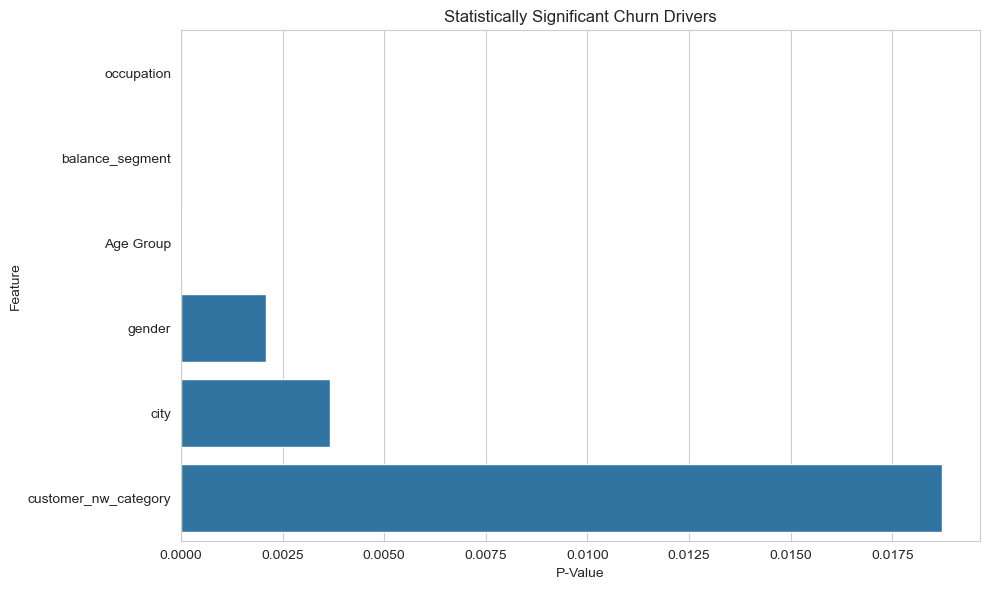

In [56]:
# Visualize Significant Drivers

plt.figure(figsize=(10,6))

sns.barplot(
    data=significant_features,
    x='P_Value',
    y='Feature'
)

plt.title(
    'Statistically Significant Churn Drivers'
)

plt.xlabel('P-Value')

plt.ylabel('Feature')

plt.tight_layout()

plt.show()

## **STEP 10: HIGH-RISK CUSTOMER ANALYSIS**

### **10.1 Objective**
To identify customer segments with elevated churn rates, quantify their business impact, and discover retention opportunities for targeted intervention.

### **10.2 Segment-Level Customer Analysis**

In [57]:
risk_segments = (
    df.groupby([
        'Age Group',
        'occupation',
        'balance_segment'
    ])
    .agg(
        customer_count=('churn', 'size'),
        churned_customers=('churn', 'sum'),
        churn_rate=('churn', 'mean')
    )
    .reset_index()
)

# Convert to percentage
risk_segments['churn_rate'] = (
    risk_segments['churn_rate'] * 100
)

risk_segments.head()

,Age Group,occupation,balance_segment,customer_count,churned_customers,churn_rate
0,18-25,Others,Low,1,0,0.000000
1,18-25,company,Low,1,0,0.000000
2,18-25,salaried,Low,116,23,19.827586
3,18-25,salaried,Medium,9,1,11.111111
4,18-25,self_employed,High,3,2,66.666667


### **10.3 High-Risk Group Identification**

In [58]:
# Filter reliable segments

risk_segments = risk_segments[
    risk_segments['customer_count'] >= 100
]

### **10.4 Risk Classification**

In [59]:
# Categorize segments based on churn rate

risk_segments['risk_level'] = pd.cut(
    risk_segments['churn_rate'],
    bins=[0,20,40,60,100],
    labels=[
        'Low Risk',
        'Moderate Risk',
        'High Risk',
        'Critical Risk'
    ]
)

risk_segments.head()

,Age Group,occupation,balance_segment,customer_count,churned_customers,churn_rate,risk_level
2,18-25,salaried,Low,116,23,19.827586,Low Risk
5,18-25,self_employed,Low,332,97,29.216867,Moderate Risk
8,18-25,student,Low,1477,227,15.368991,Low Risk
9,18-25,student,Medium,104,12,11.538462,Low Risk
15,26-35,salaried,Low,1486,290,19.515478,Low Risk


### **10.5 Top 10 High-Risk Segments**

In [60]:
# Top risk Segments

top_risk_segments = (
    risk_segments
    .sort_values(
        by='churn_rate',
        ascending=False
    )
    .head(10)
)

top_risk_segments

,Age Group,occupation,balance_segment,customer_count,churned_customers,churn_rate,risk_level
5,18-25,self_employed,Low,332,97,29.216867,Moderate Risk
18,26-35,self_employed,Low,2528,597,23.615506,Moderate Risk
47,46-55,self_employed,Low,3120,657,21.057692,Moderate Risk
33,36-45,self_employed,Low,4042,832,20.583869,Moderate Risk
2,18-25,salaried,Low,116,23,19.827586,Low Risk
15,26-35,salaried,Low,1486,290,19.515478,Low Risk
64,55+,self_employed,Low,4719,911,19.304937,Low Risk
44,46-55,salaried,Low,1298,247,19.029276,Low Risk
21,26-35,student,Low,400,74,18.500000,Low Risk
30,36-45,salaried,Low,1725,316,18.318841,Low Risk


### **10.6 Visualize Top High-Risk Segments**

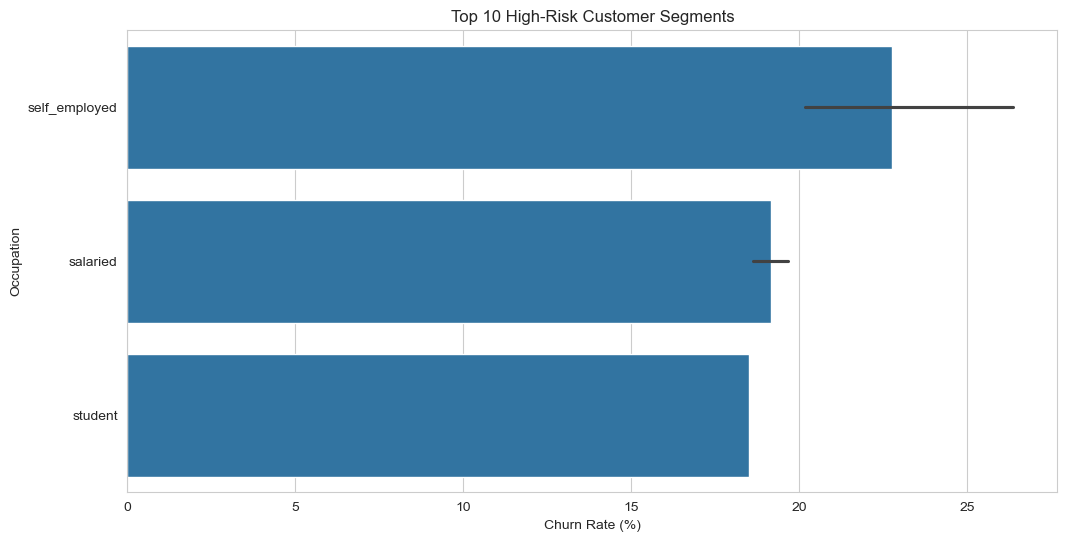

In [61]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_risk_segments,
    x='churn_rate',
    y='occupation'
)

plt.title(
    'Top 10 High-Risk Customer Segments'
)

plt.xlabel('Churn Rate (%)')
plt.ylabel('Occupation')

plt.show()

### **10.7 Retention Opportunity Detection**

In [62]:
risk_segments.shape

(24, 7)

In [63]:
risk_segments[['customer_count','churn_rate']].describe()

,customer_count,churn_rate
count,24.000000,24.000000
mean,1161.125000,15.964783
std,1280.775251,5.453925
min,104.000000,4.326923
25%,256.500000,12.478508
50%,584.500000,15.934616
75%,1541.750000,19.357573
max,4719.000000,29.216867


In [64]:
risk_segments.sort_values(
    by='churn_rate',
    ascending=False
).head(20)

,Age Group,occupation,balance_segment,customer_count,churned_customers,churn_rate,risk_level
5,18-25,self_employed,Low,332,97,29.216867,Moderate Risk
18,26-35,self_employed,Low,2528,597,23.615506,Moderate Risk
47,46-55,self_employed,Low,3120,657,21.057692,Moderate Risk
33,36-45,self_employed,Low,4042,832,20.583869,Moderate Risk
2,18-25,salaried,Low,116,23,19.827586,Low Risk
15,26-35,salaried,Low,1486,290,19.515478,Low Risk
64,55+,self_employed,Low,4719,911,19.304937,Low Risk
44,46-55,salaried,Low,1298,247,19.029276,Low Risk
21,26-35,student,Low,400,74,18.500000,Low Risk
30,36-45,salaried,Low,1725,316,18.318841,Low Risk


In [65]:
# High customer count + High churn rate

retention_opportunities = risk_segments[
    (risk_segments['customer_count'] >= 50) &
    (risk_segments['churn_rate'] >= 20)
].copy()

retention_opportunities.head()

,Age Group,occupation,balance_segment,customer_count,churned_customers,churn_rate,risk_level
5,18-25,self_employed,Low,332,97,29.216867,Moderate Risk
18,26-35,self_employed,Low,2528,597,23.615506,Moderate Risk
33,36-45,self_employed,Low,4042,832,20.583869,Moderate Risk
47,46-55,self_employed,Low,3120,657,21.057692,Moderate Risk


### **10.8 Assign Business Priority**

In [66]:
retention_opportunities['Business_Priority'] = pd.cut(
    retention_opportunities['customer_count'],
    bins=[0, 200, 500, 1000, float('inf')],
    labels=[
        'Low',
        'Medium',
        'High',
        'Critical'
    ]
)

retention_opportunities.head(5)

,Age Group,occupation,balance_segment,customer_count,churned_customers,churn_rate,risk_level,Business_Priority
5,18-25,self_employed,Low,332,97,29.216867,Moderate Risk,Medium
18,26-35,self_employed,Low,2528,597,23.615506,Moderate Risk,Critical
33,36-45,self_employed,Low,4042,832,20.583869,Moderate Risk,Critical
47,46-55,self_employed,Low,3120,657,21.057692,Moderate Risk,Critical


### **10.9 Recommended Retention Actions**

In [67]:
def recommend_action(churn_rate):

    if churn_rate >= 60:
        return 'Immediate Retention Campaign'

    elif churn_rate >= 50:
        return 'Personalized Customer Engagement'

    elif churn_rate >= 40:
        return 'Targeted Follow-Up'

    else:
        return 'Monitor'


retention_opportunities['Recommended_Action'] = (
    retention_opportunities['churn_rate']
    .apply(recommend_action)
)

### **10.10 Opportunity Scoring**

In [68]:
# Higher score = Higher business impact

retention_opportunities['Opportunity_Score'] = (
    retention_opportunities['customer_count']
    *
    retention_opportunities['churn_rate']
) / 100

### **10.11 Rank Retention Opportunities**

In [69]:
retention_opportunities = (
    retention_opportunities
    .sort_values(
        by='Opportunity_Score',
        ascending=False
    )
)

retention_opportunities.head(10)

,Age Group,occupation,balance_segment,customer_count,churned_customers,churn_rate,risk_level,Business_Priority,Recommended_Action,Opportunity_Score
33,36-45,self_employed,Low,4042,832,20.583869,Moderate Risk,Critical,Monitor,832.0
47,46-55,self_employed,Low,3120,657,21.057692,Moderate Risk,Critical,Monitor,657.0
18,26-35,self_employed,Low,2528,597,23.615506,Moderate Risk,Critical,Monitor,597.0
5,18-25,self_employed,Low,332,97,29.216867,Moderate Risk,Medium,Monitor,97.0


### **10.12 Final Retention Opportunity Summary**

In [70]:
retention_summary = retention_opportunities[
    [
        'Age Group',
        'occupation',
        'balance_segment',
        'customer_count',
        'churned_customers',
        'churn_rate',
        'risk_level',
        'Business_Priority',
        'Opportunity_Score',
        'Recommended_Action'
    ]
]

retention_summary.head(10)

,Age Group,occupation,balance_segment,customer_count,churned_customers,churn_rate,risk_level,Business_Priority,Opportunity_Score,Recommended_Action
33,36-45,self_employed,Low,4042,832,20.583869,Moderate Risk,Critical,832.0,Monitor
47,46-55,self_employed,Low,3120,657,21.057692,Moderate Risk,Critical,657.0,Monitor
18,26-35,self_employed,Low,2528,597,23.615506,Moderate Risk,Critical,597.0,Monitor
5,18-25,self_employed,Low,332,97,29.216867,Moderate Risk,Medium,97.0,Monitor


### **10.13 Key Findings**

In [71]:
print("=" * 60)
print("HIGH-RISK CUSTOMER ANALYSIS SUMMARY")
print("=" * 60)

print(
    f"Total Reliable Segments: "
    f"{len(risk_segments)}"
)

print(
    f"Retention Opportunities Identified: "
    f"{len(retention_opportunities)}"
)

print(
    f"Average Churn Rate: "
    f"{risk_segments['churn_rate'].mean():.2f}%"
)

print(
    f"Highest Churn Rate: "
    f"{risk_segments['churn_rate'].max():.2f}%"
)

HIGH-RISK CUSTOMER ANALYSIS SUMMARY
Total Reliable Segments: 24
Retention Opportunities Identified: 4
Average Churn Rate: 15.96%
Highest Churn Rate: 29.22%


## **STEP 11: MACHINE LEARNING PREPARATION**

### **11.1 Objective**
To prepare the dataset for machine learning by handling missing values, encoding categorical variables, scaling numerical features, and creating training and testing datasets.

### **11.2 Define Target Variable (y)**

In [72]:
# Target Variable
y = df['churn']

### **11.3 Define Features (X)**

In [73]:
# Features
X = df.drop('churn', axis=1)

### **11.4 Drop Irrelevant Columns**

In [74]:
# Save Customer IDs for future use

customer_ids = X['customer_id'].copy()

In [75]:
# Remove ID Columns

X = X.drop(['customer_id'], axis=1)

In [76]:
# Remove raw Date Column

X = X.drop('last_transaction', axis=1)

### **11.5 Handle Missing Values**

In [77]:
X = X.fillna(0)

In [78]:
X.isnull().sum().sort_values(ascending=False)

vintage                           0
vintage (in years)                0
credit_change                     0
balance_change_pct                0
days_since_last_transaction       0
previous_month_balance            0
current_month_balance             0
previous_month_debit              0
current_month_debit               0
previous_month_credit             0
current_month_credit              0
average_monthly_balance_prevQ2    0
average_monthly_balance_prevQ     0
previous_month_end_balance        0
balance_segment                   0
current_balance                   0
branch_code                       0
customer_nw_category              0
city                              0
occupation                        0
dependents                        0
gender                            0
Age Group                         0
age                               0
vintage_segment                   0
debit_change                      0
dtype: int64

### **11.6 One-Hot Encoding**

In [79]:
# Converting Categorical Features into Numerical Features

X = pd.get_dummies(
    X,
    drop_first=True
)

### **11.7 Train-Test Split**

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### **11.8 Feature Scaling (For Logistic Regression)**

In [81]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Business Interpretation

Categorical variables were transformed into numerical representations suitable for machine learning algorithms. Feature engineering ensures that all input variables are compatible with predictive models.

## **STEP 12: MACHINE LEARNING MODELS**

### **12.1 Logistic Regression**

**12.1.1 Train Logistic Regression**

In [82]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


**12.1.2 Make Predictions - Logistic Regression**

In [83]:
y_pred_lr = lr.predict(
    X_test_scaled
)

**12.1.3 Predict Probabilities - Logistic Regression**

In [84]:
y_prob_lr = lr.predict_proba(
    X_test_scaled
)[:,1]

### **12.2 - Decision Tree Model**

**12.2.1 Train Decision Tree**

In [85]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


**12.2.2 Make Predictions - Decision Tree**

In [86]:
y_pred_dt = dt.predict(
    X_test
)

**12.2.3 Predict Probabilities - Decision Tree**

In [87]:
y_prob_dt = dt.predict_proba(
    X_test
)[:,1]

### **12.3 - Random Forest**

**12.3.1 Train Random Forest**

In [88]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**12.3.2 Make Predictions - Random Forest**

In [89]:
y_pred_rf = rf.predict(X_test)

**12.3.3 Predict Probabilities - Random Forest**

In [90]:
y_prob_rf = rf.predict_proba(X_test)[:,1]

### **12.4 - XGBoost**

**12.4.1 Train Xgboost**

In [91]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


**12.4.2 Make Predictions - XGBoost**

In [92]:
y_pred_xgb = xgb.predict(
    X_test
)

**12.4.3 Predict Probabilities - XGBoost**

In [93]:
y_prob_xgb = xgb.predict_proba(
    X_test
)[:,1]

## **STEP 13: MODEL EVALUATION**

### **13.1 Logistic Regression Evaluation**

In [94]:
# Accuracy
acc_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print("Accuracy:", round(acc_lr,4))

# Precision
precision_lr = precision_score(
    y_test,
    y_pred_lr
)

print("Precision:", round(precision_lr,4))

# Recall
recall_lr = recall_score(
    y_test,
    y_pred_lr
)

print("Recall:", round(recall_lr,4))

# F1 Score
f1_lr = f1_score(
    y_test,
    y_pred_lr
)

print("F1 Score:", round(f1_lr,4))

# ROC-AUC
roc_auc_lr = roc_auc_score(
    y_test,
    y_prob_lr
)

print("ROC-AUC:", round(roc_auc_lr,4))

Accuracy: 0.8202
Precision: 0.6962
Recall: 0.0523
F1 Score: 0.0973
ROC-AUC: 0.7703


**Confusion Matrix**

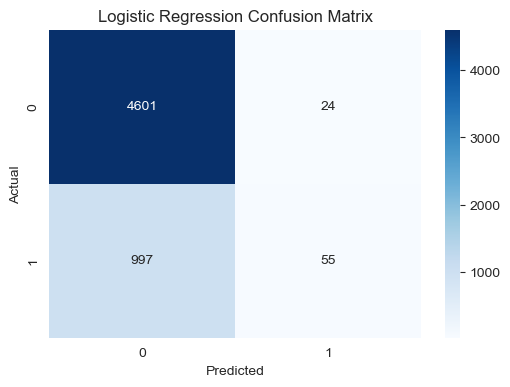

In [95]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Logistic Regression Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

**Classification Report**

In [96]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.82      0.99      0.90      4625
           1       0.70      0.05      0.10      1052

    accuracy                           0.82      5677
   macro avg       0.76      0.52      0.50      5677
weighted avg       0.80      0.82      0.75      5677



### **13.2 Decision Tree Evaluation**

In [97]:
# Accuracy
acc_dt = accuracy_score(
    y_test,
    y_pred_dt
)

print("Accuracy:", round(acc_dt,4))

# Precision
precision_dt = precision_score(
    y_test,
    y_pred_dt
)

print("Precision:", round(precision_dt,4))

# Recall
recall_dt = recall_score(
    y_test,
    y_pred_dt
)

print("Recall:", round(recall_dt,4))

# F1 Score
f1_dt = f1_score(
    y_test,
    y_pred_dt
)

print("F1 Score:", round(f1_dt,4))

# ROC-AUC
roc_auc_dt = roc_auc_score(
    y_test,
    y_prob_dt
)

print("ROC-AUC:", round(roc_auc_dt,4))

Accuracy: 0.8522
Precision: 0.6833
Recall: 0.3774
F1 Score: 0.4862
ROC-AUC: 0.814


**Confusion Matrix**

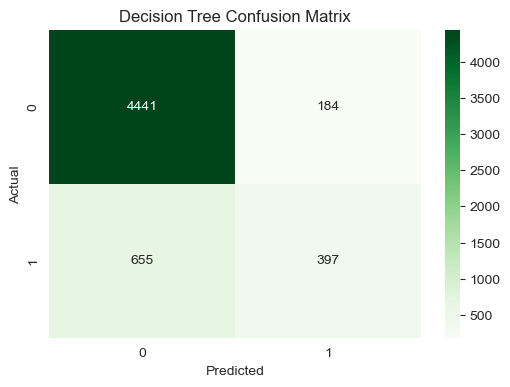

In [98]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    'Decision Tree Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

**Classification Report**

In [99]:
print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      4625
           1       0.68      0.38      0.49      1052

    accuracy                           0.85      5677
   macro avg       0.78      0.67      0.70      5677
weighted avg       0.84      0.85      0.83      5677



### **13.3 Random Forest Evaluation**

In [100]:
# Accuracy
acc_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print("Accuracy:", round(acc_rf,4))

# Precision
precision_rf = precision_score(
    y_test,
    y_pred_rf
)

print("Precision:", round(precision_rf,4))

# Recall
recall_rf = recall_score(
    y_test,
    y_pred_rf
)

print("Recall:", round(recall_rf,4))

# F1 Score
f1_rf = f1_score(
    y_test,
    y_pred_rf
)

print("F1 Score:", round(f1_rf,4))

# ROC-AUC
roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print("ROC-AUC:", round(roc_auc_rf,4))

Accuracy: 0.858
Precision: 0.7269
Recall: 0.3745
F1 Score: 0.4944
ROC-AUC: 0.8449


**Confusion Matrix**

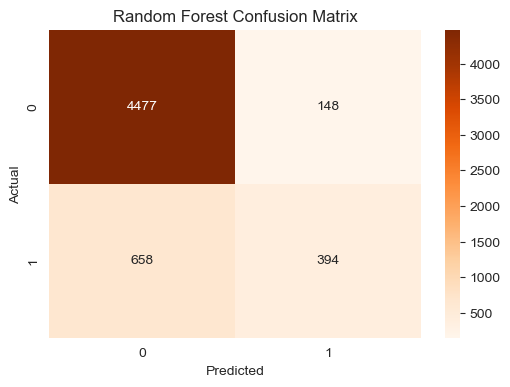

In [101]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title(
    'Random Forest Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

**Classification Report**

In [102]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      4625
           1       0.73      0.37      0.49      1052

    accuracy                           0.86      5677
   macro avg       0.80      0.67      0.71      5677
weighted avg       0.85      0.86      0.84      5677



### **13.4 XGBoost Evaluation**

In [103]:
# Accuracy
acc_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

print("Accuracy:", round(acc_xgb,4))

# Precision
precision_xgb = precision_score(
    y_test,
    y_pred_xgb
)

print("Precision:", round(precision_xgb,4))

# Recall
recall_xgb = recall_score(
    y_test,
    y_pred_xgb
)

print("Recall:", round(recall_xgb,4))

# F1 Score
f1_xgb = f1_score(
    y_test,
    y_pred_xgb
)

print("F1 Score:", round(f1_xgb,4))

# ROC-AUC
roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("ROC-AUC:", round(roc_auc_xgb,4))

Accuracy: 0.86
Precision: 0.6753
Recall: 0.4705
F1 Score: 0.5546
ROC-AUC: 0.8278


**Confusion Matrix**

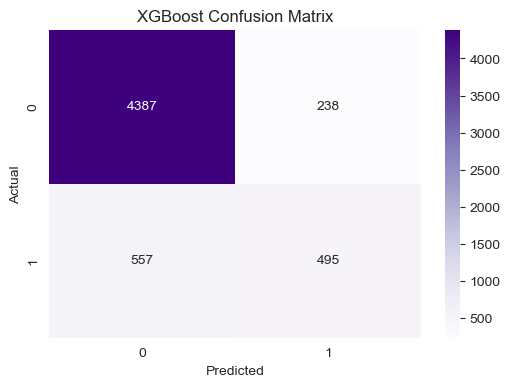

In [104]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title(
    'XGBoost Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

**Classification Report**

In [105]:
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      4625
           1       0.68      0.47      0.55      1052

    accuracy                           0.86      5677
   macro avg       0.78      0.71      0.74      5677
weighted avg       0.85      0.86      0.85      5677



### Business Interpretation

The evaluation metrics demonstrate each model's ability to distinguish between customers who are likely to churn and those who are expected to remain. Multiple metrics provide a balanced assessment of predictive performance.

## **STEP 14: MODEL COMPARISON**

### **14.1 Objective**
To evaluate and compare the predictive performance of all candidate models using standard classification metrics.

In [106]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],

    # Accuracy Comparison
    'Accuracy':[
        acc_lr,
        acc_dt,
        acc_rf,
        acc_xgb
    ],

    # Precision Comparison
    'Precision':[
        precision_lr,
        precision_dt,
        precision_rf,
        precision_xgb
    ],

    # Recall Comparison
    'Recall':[
        recall_lr,
        recall_dt,
        recall_rf,
        recall_xgb
    ],

    # F1 Comparison
    'F1 Score':[
        f1_lr,
        f1_dt,
        f1_rf,
        f1_xgb
    ],

    # ROC-AUC Comparison
    'ROC-AUC':[
        roc_auc_lr,
        roc_auc_dt,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

results.sort_values(
    by='ROC-AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.858024,0.726937,0.374525,0.494354,0.844927
3,XGBoost,0.859961,0.675307,0.470532,0.554622,0.827815
1,Decision Tree,0.852211,0.683305,0.377376,0.486222,0.813997
0,Logistic Regression,0.820151,0.696203,0.052281,0.097259,0.770251


## **STEP 15: CROSS VALIDATION**

### **15.1 Objective**
To assess model stability and generalization capability across multiple data samples.

**For All Models**

In [107]:
models = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb
}

cv_results = []

for name, model in models.items():

    if name == 'Logistic Regression':

        score = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5,
            scoring='roc_auc'
        )

    else:

        score = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring='roc_auc'
        )

    cv_results.append([
        name,
        score.mean(),
        score.std()
    ])

cv_results = pd.DataFrame(
    cv_results,
    columns=[
        'Model',
        'Mean ROC-AUC',
        'Std Dev'
    ]
)

cv_results

,Model,Mean ROC-AUC,Std Dev
0,Logistic Regression,0.754956,0.012983
1,Decision Tree,0.799035,0.010563
2,Random Forest,0.832794,0.006777
3,XGBoost,0.816030,0.005190


### Business Interpretation

Cross-validation confirms the stability and reliability of the machine learning models by evaluating their performance across multiple data partitions, reducing the risk of overfitting.

## **STEP 16: FINAL MODEL SELECTION**

### **16.1 Objective**
To identify the model that provides the optimal balance between predictive accuracy, churn detection capability, and generalization performance.

In [108]:
best_model_row = results.loc[
    results['ROC-AUC'].idxmax()
]

best_model_row

Model        Random Forest
Accuracy          0.858024
Precision         0.726937
Recall            0.374525
F1 Score          0.494354
ROC-AUC           0.844927
Name: 2, dtype: object

In [109]:
best_model_name = best_model_row['Model']

print(
    f"Best Model Selected: {best_model_name}"
)

Best Model Selected: Random Forest


In [110]:
final_model_summary = results.merge(
    cv_results,
    on='Model'
)

final_model_summary

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Mean ROC-AUC,Std Dev
0,Logistic Regression,0.820151,0.696203,0.052281,0.097259,0.770251,0.754956,0.012983
1,Decision Tree,0.852211,0.683305,0.377376,0.486222,0.813997,0.799035,0.010563
2,Random Forest,0.858024,0.726937,0.374525,0.494354,0.844927,0.832794,0.006777
3,XGBoost,0.859961,0.675307,0.470532,0.554622,0.827815,0.816030,0.005190


In [111]:
final_model_summary.sort_values(
    by=['ROC-AUC','Recall'],
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Mean ROC-AUC,Std Dev
2,Random Forest,0.858024,0.726937,0.374525,0.494354,0.844927,0.832794,0.006777
3,XGBoost,0.859961,0.675307,0.470532,0.554622,0.827815,0.816030,0.005190
1,Decision Tree,0.852211,0.683305,0.377376,0.486222,0.813997,0.799035,0.010563
0,Logistic Regression,0.820151,0.696203,0.052281,0.097259,0.770251,0.754956,0.012983


### Business Interpretation

Random Forest demonstrated the strongest overall predictive performance based on evaluation metrics and cross-validation results. Therefore, it was selected as the final model for customer churn prediction.

## **STEP 17: FEATURE IMPORTANCE ANALYSIS** - **Random Forest Feature Importance**

### **17.1 Objective**
To identify the most influential variables driving churn predictions and understand the key factors contributing to customer attrition.

### **17.2 Extract Feature Importance**

In [112]:
importance_rfc = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_rfc.head()

,Feature,Importance
0,vintage,0.033918
1,vintage (in years),0.022928
2,age,0.031507
3,dependents,0.006113
4,city,0.030122


### **17.3 Rank Features**

In [113]:
feature_importance = (
    importance_rfc
    .sort_values(
        by='Importance',
        ascending=False
    )
)

top_features = feature_importance.head(10)

top_features

,Feature,Importance
7,current_balance,0.131528
18,balance_change_pct,0.124791
13,current_month_debit,0.064167
15,current_month_balance,0.060485
20,debit_change,0.052064
10,average_monthly_balance_prevQ2,0.050260
14,previous_month_debit,0.048972
9,average_monthly_balance_prevQ,0.044382
16,previous_month_balance,0.042590
8,previous_month_end_balance,0.042205


### **17.4 Top 10 Most Important Features**

In [114]:
top_features = importance_rfc.head(10)

top_features

,Feature,Importance
0,vintage,0.033918
1,vintage (in years),0.022928
2,age,0.031507
3,dependents,0.006113
4,city,0.030122
5,customer_nw_category,0.008473
6,branch_code,0.036999
7,current_balance,0.131528
8,previous_month_end_balance,0.042205
9,average_monthly_balance_prevQ,0.044382


### **17.5 Visualization**

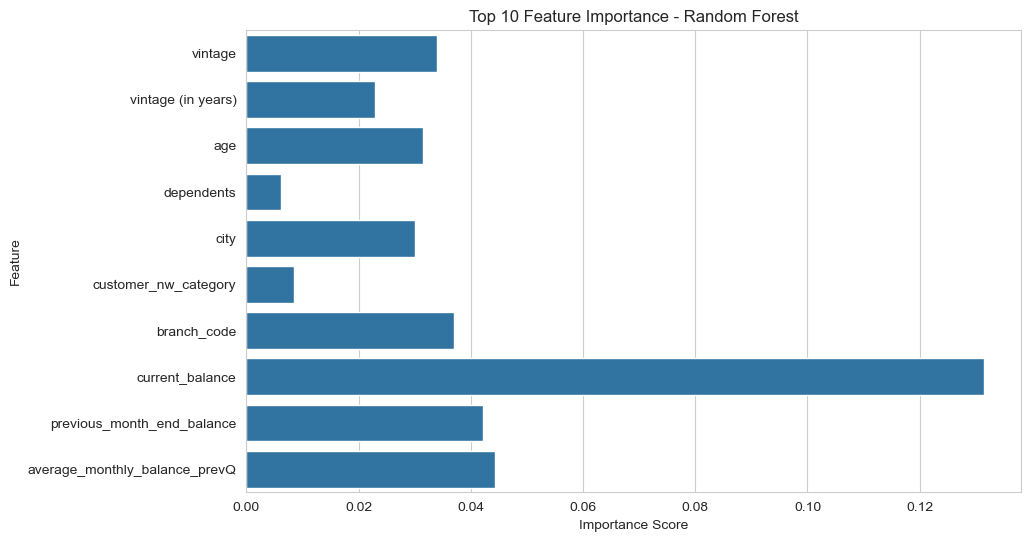

In [115]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 10 Feature Importance - Random Forest'
)

plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()

### **17.6 Key Churn Drivers**

In [116]:
top_features

,Feature,Importance
0,vintage,0.033918
1,vintage (in years),0.022928
2,age,0.031507
3,dependents,0.006113
4,city,0.030122
5,customer_nw_category,0.008473
6,branch_code,0.036999
7,current_balance,0.131528
8,previous_month_end_balance,0.042205
9,average_monthly_balance_prevQ,0.044382


### Business Interpretation

The feature importance analysis identifies the variables that contribute most to churn prediction. These insights help the bank understand the primary drivers of customer attrition and support targeted retention strategies.

## **Transition to Predictive Analytics**

The exploratory data analysis and machine learning evaluation identified the most suitable model for customer churn prediction.

The following sections apply the selected Random Forest model to predict customer churn, estimate churn probabilities, identify high-risk customers, and generate business-ready outputs for decision-making and Power BI visualization.

## **STEP 18: CUSTOMER CHURN PREDICTION AND BUSINESS INTELLIGENCE**

### **18.1 Objective**

Predict customer churn for every customer using the final Random Forest model to identify customers who are most likely to leave the bank.

### **18.2 Predict Customer Churn**

In [117]:
# Predict churn for all customers
predicted_churn = rf.predict(X)

# Create prediction dataframe
prediction_df = pd.DataFrame({
    'Predicted_Churn': predicted_churn
})

prediction_df.head()

,Predicted_Churn
0,0
1,0
2,0
3,1
4,0


### Business Interpretation

The trained Random Forest model successfully predicted churn outcomes for all customers. These predictions enable the bank to proactively identify customers who are at risk of leaving.

### **18.3 Churn Probability Analysis**

**Objective**

Estimate the probability of customer churn for each customer to measure prediction confidence and support risk-based customer segmentation.

In [118]:
# Predict probability of churn
churn_probability = rf.predict_proba(X)[:, 1]

# Add probability column
prediction_df['Churn_Probability'] = churn_probability

prediction_df.head()

,Predicted_Churn,Churn_Probability
0,0,0.015
1,0,0.185
2,0,0.135
3,1,0.650
4,0,0.335


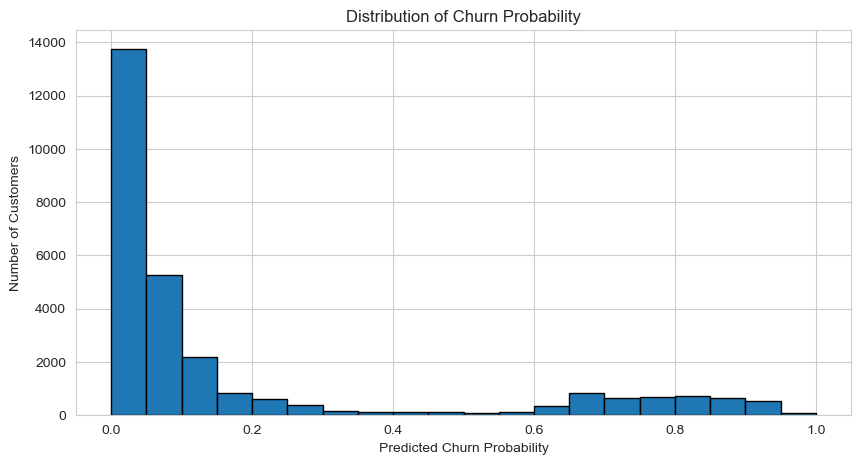

In [119]:
plt.figure(figsize=(10,5))

plt.hist(
    prediction_df["Churn_Probability"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Churn Probability")

plt.xlabel("Predicted Churn Probability")

plt.ylabel("Number of Customers")

plt.show()

### Business Interpretation

Churn probabilities provide confidence scores for each prediction. Customers with higher probabilities represent greater churn risk and should be prioritised for retention initiatives.

**Churn Probability Distribution**

In [120]:
prediction_df["Probability_Range"] = pd.cut(
    prediction_df["Churn_Probability"],
    bins=[0, 0.20, 0.40, 0.60, 0.80, 1.00],
    labels=[
        "0-20%",
        "20-40%",
        "40-60%",
        "60-80%",
        "80-100%"
    ],
    include_lowest=True
)

### **18.4 Customer Risk Segmentation**

**18.4.1 Objective**

Categorize customers into business-friendly risk levels based on predicted churn probabilities to prioritize customer retention efforts effectively.

**18.4.2 Create Risk Level**

In [121]:
def assign_risk(probability):

    if probability >= 0.90:
        return "Very High"

    elif probability >= 0.70:
        return "High"

    elif probability >= 0.50:
        return "Medium"

    else:
        return "Low"

In [122]:
prediction_df["Risk_Level"] = prediction_df["Churn_Probability"].apply(assign_risk)

**18.4.3 Create Retention Priority**

In [123]:
def retention_priority(risk):

    if risk == "Very High":
        return "Immediate"

    elif risk == "High":
        return "High"

    elif risk == "Medium":
        return "Medium"

    else:
        return "Monitor"

In [124]:
prediction_df["Retention_Priority"] = prediction_df["Risk_Level"].apply(retention_priority)

**18.4.4 Recommended Action**

In [125]:
def recommendation(risk):

    if risk == "Very High":
        return "Immediate Relationship Manager Intervention"

    elif risk == "High":
        return "Targeted Retention Campaign"

    elif risk == "Medium":
        return "Offer Personalized Banking Benefits"

    else:
        return "Regular Customer Engagement"

In [126]:
prediction_df["Recommended_Action"] = prediction_df["Risk_Level"].apply(recommendation)

prediction_df.head()

,Predicted_Churn,Churn_Probability,Probability_Range,Risk_Level,Retention_Priority,Recommended_Action
0,0,0.015,0-20%,Low,Monitor,Regular Customer Engagement
1,0,0.185,0-20%,Low,Monitor,Regular Customer Engagement
2,0,0.135,0-20%,Low,Monitor,Regular Customer Engagement
3,1,0.650,60-80%,Medium,Medium,Offer Personalized Banking Benefits
4,0,0.335,20-40%,Low,Monitor,Regular Customer Engagement


**18.4.5 Risk Distribution**

In [127]:
risk_summary = (
    prediction_df
    .groupby("Risk_Level")
    .size()
    .reset_index(name="Customer_Count")
)

risk_summary["Percentage"] = (
    risk_summary["Customer_Count"] /
    risk_summary["Customer_Count"].sum()
    *100
).round(2)

risk_summary

,Risk_Level,Customer_Count,Percentage
0,High,2799,9.86
1,Low,23618,83.21
2,Medium,1344,4.74
3,Very High,621,2.19


### Business Interpretation

Segmenting customers into risk categories enables the business to allocate retention resources more efficiently. Immediate attention should be given to customers classified as Very High or High risk.

### **18.5 Business Scenario Analysis**

**18.5.1 Objective**

Evaluate different customer retention scenarios and estimate their potential impact on future customer churn to support strategic business decision-making.

**18.5.2 Current Prediction**

In [128]:
# Total customers
total_customers = len(prediction_df)

# Total predicted churn customers
predicted_churn = prediction_df["Predicted_Churn"].sum()

# Predicted churn rate
predicted_churn_rate = (predicted_churn / total_customers) * 100

**18.5.3 Scenario Table**

In [129]:
scenario_df = pd.DataFrame({

    "Scenario":[
        "No Retention Strategy",
        "10% Reduction",
        "20% Reduction",
        "30% Reduction"
    ],

    "Expected_Churn_Customers":[
        predicted_churn,
        int(predicted_churn*0.90),
        int(predicted_churn*0.80),
        int(predicted_churn*0.70)
    ]
})

scenario_df["Customers_Retained"] = (
    predicted_churn -
    scenario_df["Expected_Churn_Customers"]
)

scenario_df

,Scenario,Expected_Churn_Customers,Customers_Retained
0,No Retention Strategy,4750,0
1,10% Reduction,4275,475
2,20% Reduction,3800,950
3,30% Reduction,3325,1425


### Business Interpretation

The scenario analysis illustrates how different customer retention strategies could influence future churn outcomes. It provides decision-makers with a framework for evaluating the potential business impact of retention campaigns.

### **18.6 Future Churn Forecast**

**Objective**

Estimate future customer churn under defined business assumptions to help visualize potential business outcomes and support long-term retention planning.

In [130]:
forecast_df = pd.DataFrame({

    "Period":[
        "Current",
        "Next Quarter",
        "Next 6 Months",
        "Next Year"
    ],

    "Forecasted_Churn":[
        predicted_churn,
        int(predicted_churn*1.03),
        int(predicted_churn*1.05),
        int(predicted_churn*1.08)
    ]
})

forecast_df

,Period,Forecasted_Churn
0,Current,4750
1,Next Quarter,4892
2,Next 6 Months,4987
3,Next Year,5130


### Business Interpretation

The forecast presents projected customer churn under predefined business assumptions. These projections support long-term planning and should be interpreted as scenario-based estimates rather than statistical forecasts.

## **STEP 19: EXPORT RESULTS TO POWER BI**

### **19.1 Objective**

Export prediction results, customer risk segments, feature importance, and business scenario datasets for interactive visualization and reporting in Power BI.

### **19.2 Prediction Results**

In [131]:
prediction_df.insert(0, "Customer_ID", customer_ids.values)

### **19.3 Export Prediction Results**

In [147]:
prediction_df.to_csv(
    r"D:\DIVYA\Data Analytics\DA Projects\Power BI\Customer Churn Prediction Analysis\data\processed\prediction_results.csv",
    index=False
)

In [133]:
print("Prediction results exported successfully.")

Prediction results exported successfully.


### **19.4 Export Risk Summary**

In [145]:
risk_summary.to_csv(
    r"D:\DIVYA\Data Analytics\DA Projects\Power BI\Customer Churn Prediction Analysis\data\processed\risk_summary.csv",
    index=False
)

In [135]:
print("Risk Summary exported successfully.")

Risk Summary exported successfully.


### **19.5 Export Business Scenarios**

In [148]:
scenario_df.to_csv(
    r"D:\DIVYA\Data Analytics\DA Projects\Power BI\Customer Churn Prediction Analysis\data\processed\business_scenarios.csv",
    index=False
)

In [137]:
print("Business Scenarios exported successfully.")

Business Scenarios exported successfully.


### **19.6 Export Forecast**

In [149]:
forecast_df.to_csv(
    r"D:\DIVYA\Data Analytics\DA Projects\Power BI\Customer Churn Prediction Analysis\data\processed\forecast_results.csv",
    index=False
)

In [139]:
print("Forecast results exported successfully.")

Forecast results exported successfully.


### **19.7 Export Feature Importance**

In [150]:
feature_importance.to_csv(
    r"D:\DIVYA\Data Analytics\DA Projects\Power BI\Customer Churn Prediction Analysis\data\processed\feature_importance.csv",
    index=False
)

In [141]:
print("Feature Importance exported successfully.")

Feature Importance exported successfully.


## **STEP 20: PROJECT SUMMARY**

In [142]:
print("="*70)

print("CUSTOMER CHURN ANALYSIS SUMMARY")

print("="*70)

print(f"Total Customers                 : {total_customers}")

print(f"Predicted Churn Customers       : {predicted_churn}")

print(f"Predicted Churn Rate            : {predicted_churn_rate:.2f}%")

print(f"Very High Risk Customers        : {(prediction_df['Risk_Level']=='Very High').sum()}")

print(f"High Risk Customers             : {(prediction_df['Risk_Level']=='High').sum()}")

print(f"Medium Risk Customers           : {(prediction_df['Risk_Level']=='Medium').sum()}")

print(f"Low Risk Customers              : {(prediction_df['Risk_Level']=='Low').sum()}")

print("="*70)

CUSTOMER CHURN ANALYSIS SUMMARY
Total Customers                 : 28382
Predicted Churn Customers       : 4750
Predicted Churn Rate            : 16.74%
Very High Risk Customers        : 621
High Risk Customers             : 2799
Medium Risk Customers           : 1344
Low Risk Customers              : 23618


## **STEP 21: BUSINESS INSIGHTS**

In [143]:
insights = pd.DataFrame({
    "Priority": [1,2,3,4,5,6,7,8,9,10],

    "Key Finding": [
        "Low balance customers churn the most",
        "Customers aged 26-35 have the highest churn rate",
        "Occupation significantly influences churn",
        "High net worth customers also show elevated churn",
        "Regular/long-term customers churn more than new customers",
        "Customers who did not disclose gender have the highest churn rate (20.1%), followed by male customers (19.2%) and female customers (17.5%).",
        "Customers with many dependents have significantly higher churn risk",
        "Overall churn rate is high at ~18.5%",
        "Demographic variables alone have weak predictive power",
        "Customer behavior and account activity are likely the main churn drivers"
    ],

    "Why Customers Churn": [
        "Low engagement and limited banking activity",
        "Young customers are more likely to switch providers for better offers",
        "Certain occupations may have different banking needs",
        "High-value customers may receive insufficient personalized attention",
        "Long-term customers may experience service fatigue or lack of rewards",
        "Customer engagement differs slightly across groups",
        "Financial pressure and family responsibilities may impact retention",
        "A substantial portion of customers are dissatisfied or disengaged",
        "Age, gender, and tenure alone do not explain churn effectively",
        "Transaction patterns and engagement levels influence churn more strongly"
    ],

    "Business Impact": [
        "Loss of potential future revenue growth",
        "Reduced customer lifetime value among a key demographic",
        "High-risk occupation groups generate more customer loss",
        "Significant revenue loss from premium customers",
        "Erosion of the existing customer base",
        "Gender-related differences exist but are relatively small. Gender alone is not a strong predictor of churn and should not be the primary focus of retention efforts.",
        "Higher risk of losing family-oriented customer segments",
        "Retention challenge affects overall profitability",
        "Poor targeting if retention is based only on demographics",
        "Missed opportunities to identify churn risk early"
    ],

    "Recommended Action": [
        "Introduce balance incentives, rewards, and proactive engagement campaigns",
        "Create youth-focused loyalty programs and personalized offers",
        "Create occupation-specific banking products  ",
        "Launch premium retention and wealth-management programs",
        "Implement loyalty rewards and periodic relationship reviews",
        "Use gender as a supporting segmentation variable while prioritizing behavioral factors such as account activity, balance levels, and transaction patterns for churn prevention strategies.",
        "Provide family-focused financial planning and support programs",
        "Establish churn prediction and early-warning systems",
        "Combine demographics with behavioral and transaction data",
        "Build ML-based churn models using balances, credits, debits, and engagement metrics"
    ]
})

insights = insights.set_index("Priority")
insights

,Key Finding,Why Customers Churn,Business Impact,Recommended Action
Priority,,,,
1,Low balance customers churn the most,Low engagement and limited banking activity,Loss of potential future revenue growth,"Introduce balance incentives, rewards, and pro..."
2,Customers aged 26-35 have the highest churn rate,Young customers are more likely to switch prov...,Reduced customer lifetime value among a key de...,Create youth-focused loyalty programs and pers...
3,Occupation significantly influences churn,Certain occupations may have different banking...,High-risk occupation groups generate more cust...,Create occupation-specific banking products
4,High net worth customers also show elevated churn,High-value customers may receive insufficient ...,Significant revenue loss from premium customers,Launch premium retention and wealth-management...
5,Regular/long-term customers churn more than ne...,Long-term customers may experience service fat...,Erosion of the existing customer base,Implement loyalty rewards and periodic relatio...
6,Customers who did not disclose gender have the...,Customer engagement differs slightly across gr...,Gender-related differences exist but are relat...,Use gender as a supporting segmentation variab...
7,Customers with many dependents have significan...,Financial pressure and family responsibilities...,Higher risk of losing family-oriented customer...,Provide family-focused financial planning and ...
8,Overall churn rate is high at ~18.5%,A substantial portion of customers are dissati...,Retention challenge affects overall profitability,Establish churn prediction and early-warning s...
9,Demographic variables alone have weak predicti...,"Age, gender, and tenure alone do not explain c...",Poor targeting if retention is based only on d...,Combine demographics with behavioral and trans...


## **STEP 22: STRATEGIC BUSINESS RECOMMENDATIONS**

### **Objective**
Provide actionable business recommendations based on
customer churn analysis, high-risk segment identification,
and machine learning model findings.

In [144]:
recommendations = pd.DataFrame({

    "Recommendation Area": [
        "Customer Retention",
        "Young Customer Engagement",
        "Premium Customer Retention",
        "Occupation-Based Marketing",
        "Loyalty Program Enhancement",
        "Family Customer Retention",
        "Behavioral Monitoring",
        "Early Warning System"
    ],

    "Recommendation": [
        "Launch targeted retention campaigns for high-risk customers",
        "Develop personalized offers and rewards for customers aged 26-35",
        "Provide premium banking benefits and relationship management services",
        "Create occupation-specific financial products and services",
        "Reward long-term customers through loyalty and recognition programs",
        "Introduce family-focused financial planning solutions",
        "Monitor transaction activity, balances, and engagement metrics regularly",
        "Deploy the Random Forest churn prediction model to identify at-risk customers"
    ],

    "Expected Benefit": [
        "Reduced customer attrition",
        "Improved retention among younger customers",
        "Reduced loss of high-value customers",
        "Improved customer satisfaction and retention",
        "Increased customer lifetime value",
        "Stronger retention among family-oriented customers",
        "Earlier detection of churn risk",
        "Proactive customer retention and reduced revenue loss"
    ]
})

recommendations

,Recommendation Area,Recommendation,Expected Benefit
0,Customer Retention,Launch targeted retention campaigns for high-r...,Reduced customer attrition
1,Young Customer Engagement,Develop personalized offers and rewards for cu...,Improved retention among younger customers
2,Premium Customer Retention,Provide premium banking benefits and relations...,Reduced loss of high-value customers
3,Occupation-Based Marketing,Create occupation-specific financial products ...,Improved customer satisfaction and retention
4,Loyalty Program Enhancement,Reward long-term customers through loyalty and...,Increased customer lifetime value
5,Family Customer Retention,Introduce family-focused financial planning so...,Stronger retention among family-oriented custo...
6,Behavioral Monitoring,"Monitor transaction activity, balances, and en...",Earlier detection of churn risk
7,Early Warning System,Deploy the Random Forest churn prediction mode...,Proactive customer retention and reduced reven...


## **STEP 23: CONCLUSION**

### **23.1 Project Summary**

This project analyzed customer churn behavior in the banking sector using exploratory data analysis, statistical testing, customer segmentation, and machine learning techniques. The objective was to identify churn drivers, predict customer attrition, and provide actionable retention strategies.

### **23.2 Key Findings**

* Customer age, balance level, occupation, and net worth category significantly influence churn behavior.
* High-risk customer segments were identified through segmentation analysis.
* Customer engagement and financial activity are stronger churn indicators than demographic factors alone.
* The overall churn rate indicates a significant customer retention challenge.

### **23.3 Model Performance**

* Multiple models were evaluated, including Logistic Regression, Decision Tree, Random Forest, and XGBoost.
* Random Forest achieved the best overall performance based on ROC-AUC, Recall, F1-Score, and Cross-Validation results.
* Therefore, Random Forest was selected as the final churn prediction model.

### **23.4 Business Impact**

* Enables proactive identification of customers at risk of churn.
* Supports targeted retention campaigns and customer engagement initiatives.
* Helps reduce customer attrition and revenue loss.
* Improves customer satisfaction and long-term customer value.

### **23.5 Final Conclusion**

The project successfully identified key churn drivers and developed an effective churn prediction model. By combining data analytics and machine learning, the bank can make data-driven decisions, improve customer retention, and implement proactive strategies to reduce churn and enhance overall business performance.